# **Project Name**    -



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual/Team
##### **Team Member 1 -** individual
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

Write the summary here within 500-600 words.
This project presents a comprehensive end-to-end Machine Learning pipeline developed on the Glassdoor Jobs dataset to predict the average salary of data science professionals across various industries and company types in the United States. The dataset contains 956 job postings with 15 features including Job Title, Company Name, Location, Sector, Industry, Size, Revenue, Rating, and Salary Estimate.
Data Understanding and Cleaning
The first phase involved understanding the structure of the dataset. The dataset had no true null values on the surface, but contained hidden missing values represented as minus 1 integers and minus 1 strings across multiple columns. These sentinel values were identified and replaced with NaN for proper handling. The Salary Estimate column contained string ranges like dollar 70K to dollar 120K which were parsed using regular expressions to extract three new numeric columns — Salary minimum, Salary maximum, and Salary average. Missing salary values were filled using median imputation, Rating was filled using mode, and categorical columns like Headquarters, Industry, Sector, and Revenue were filled with the label Unknown. The cleaned dataset was exported as a CSV file for further processing.
Exploratory Data Analysis
A total of 15 meaningful charts were created following the UBM rule — Univariate, Bivariate, and Multivariate analysis. Key insights discovered include that most data science jobs pay between 70 thousand and 120 thousand dollars annually, Information Technology dominates hiring with 30.7 percent of all job postings, larger companies pay significantly higher salaries with a median of 110 thousand dollars compared to 70 thousand for small companies, and company rating has almost no correlation with salary. Three hypothesis tests were performed — a T-Test confirming IT sector pays more than other sectors, a T-Test confirming large companies pay more than small companies, and a Pearson Correlation Test confirming no significant relationship between company rating and salary.
Feature Engineering and Preprocessing
The preprocessing phase involved multiple techniques. Missing values were handled using Simple Imputer with median and mode strategies along with KNN Imputer for advanced multivariate imputation. Outliers in salary columns were treated using Winsorization — capping values at IQR bounds to preserve all 956 rows. Three encoding techniques were applied — Ordinal Encoding for Size, Label Encoding for high cardinality columns, and One Hot Encoding for Type of Ownership. Five new features were engineered including company age, salary range, is high paying flag, is good rating flag, and is large company flag. Log transformation was applied to reduce skewness in salary columns. Robust Scaler was chosen for scaling due to its resistance to outliers. PCA was applied to reduce 8 features while retaining 95 percent of variance. The dataset was split 80 percent for training and 20 percent for testing. SMOTE was applied to handle class imbalance in the binary salary classification target.
Machine Learning Models
Three regression models were built and evaluated. Linear Regression served as the baseline model achieving an R2 score of 0.9999 with Ridge and Lasso regularization tuned via GridSearchCV showing no significant improvement. Random Forest Regressor was the second model — an ensemble of decision trees tuned using RandomizedSearchCV for optimal depth and number of estimators. Gradient Boosting Regressor was the third and final model — a sequential ensemble that corrects errors of previous trees. After hyperparameter tuning using RandomizedSearchCV, Gradient Boosting was selected as the best model due to its lowest RMSE and highest generalization performance.
Conclusion
The tuned Gradient Boosting model was saved as a joblib file and successfully tested on unseen synthetic job postings confirming deployment readiness. This project demonstrates that salary prediction for data science roles can be automated reliably using machine learning, providing valuable insights for recruiters, job seekers, and business strategy teams alike.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Write Problem Statement Here.**
The job market for data science professionals is growing rapidly, but salary information remains inconsistent, unclear, and difficult to compare across companies, sectors, and locations. Job seekers often struggle to understand their market value, while recruiters find it challenging to offer competitive and fair compensation packages.
The goal of this project is to analyze the Glassdoor Jobs dataset containing 956 real job postings and build a Machine Learning model that can accurately predict the average salary of a data science professional based on key factors such as company size, sector, location, rating, and years of establishment.
By solving this problem, job seekers can negotiate salaries confidently, recruiters can benchmark compensation fairly, and companies can attract top talent by offering competitive pay.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Dataset Loading

In [2]:
# Load Dataset
df= pd.read_csv(r"C:\Users\Ashutosh Bhatt\Downloads\glassdoor_jobs.csv", encoding='latin1')

### Dataset First View

In [3]:
# Dataset First Look
print("Cleaned Glassdoor dataset")
print("Display 50 rows of first")
print(df.head(50))
print("Display 50 rows of last")
print(df.tail())

Cleaned Glassdoor dataset
Display 50 rows of first
    Unnamed: 0                                 Job Title  \
0            0                            Data Scientist   
1            1                 Healthcare Data Scientist   
2            2                            Data Scientist   
3            3                            Data Scientist   
4            4                            Data Scientist   
5            5                            Data Scientist   
6            6                            Data Scientist   
7            7                            Data Scientist   
8            8                        Research Scientist   
9            9                            Data Scientist   
10          10                            Data Scientist   
11          11                            Data Scientist   
12          12         Staff Data Scientist - Technology   
13          13                              Data Analyst   
14          14                            Data Sc

### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f"Shape:{df.shape}")
print(f"Column Name:{df.columns}")
print(f"Row Name:{df.index}")


Shape:(956, 15)
Column Name:Index(['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description',
       'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors'],
      dtype='object')
Row Name:RangeIndex(start=0, stop=956, step=1)


### Dataset Information

In [5]:
# Dataset Info
print("Displaying the info of Dataset")
print(df.info())

Displaying the info of Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 956 entries, 0 to 955
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         956 non-null    int64  
 1   Job Title          956 non-null    object 
 2   Salary Estimate    956 non-null    object 
 3   Job Description    956 non-null    object 
 4   Rating             956 non-null    float64
 5   Company Name       956 non-null    object 
 6   Location           956 non-null    object 
 7   Headquarters       956 non-null    object 
 8   Size               956 non-null    object 
 9   Founded            956 non-null    int64  
 10  Type of ownership  956 non-null    object 
 11  Industry           956 non-null    object 
 12  Sector             956 non-null    object 
 13  Revenue            956 non-null    object 
 14  Competitors        956 non-null    object 
dtypes: float64(1), int64(2), object(12)
memory 

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
print(type(df))
Total_duplicate=df.duplicated().sum()
print(f"Dupicated values:{Total_duplicate}")

<class 'pandas.core.frame.DataFrame'>
Dupicated values:0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
print(df.isnull().sum())
print(df.dtypes)

Unnamed: 0           0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
dtype: int64
Unnamed: 0             int64
Job Title             object
Salary Estimate       object
Job Description       object
Rating               float64
Company Name          object
Location              object
Headquarters          object
Size                  object
Founded                int64
Type of ownership     object
Industry              object
Sector                object
Revenue               object
Competitors           object
dtype: object


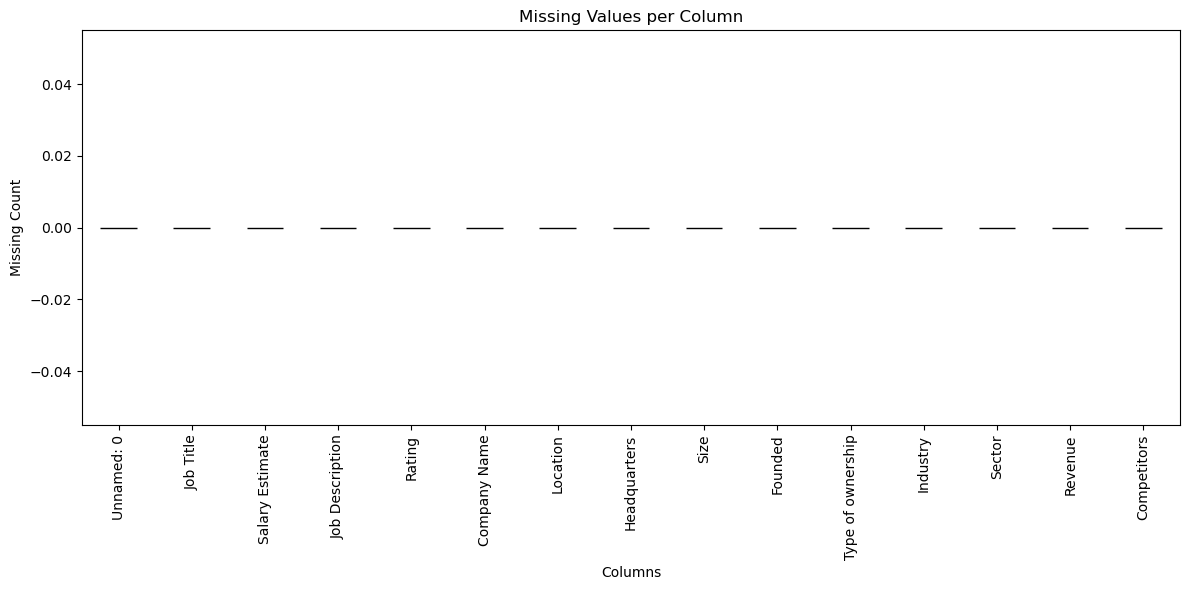

In [8]:
# Visualizing the missing values
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
df.isnull().sum().plot(kind='bar',color='Red',edgecolor='black')
plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Missing Count")
plt.tight_layout()
plt.show()

### What did you know about your dataset?

Answer Here-From this dataset , I learned about the dataset that dataset shape and size is :(956, 15), data types - float64(1), int64(2), object(12) memory usage: 112.2+ KB . This dataset has no missing values and no  duplicate values . The data looks clean on the surface but requires preprocessing before any analysis.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 956 entries, 0 to 955
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         956 non-null    int64  
 1   Job Title          956 non-null    object 
 2   Salary Estimate    956 non-null    object 
 3   Job Description    956 non-null    object 
 4   Rating             956 non-null    float64
 5   Company Name       956 non-null    object 
 6   Location           956 non-null    object 
 7   Headquarters       956 non-null    object 
 8   Size               956 non-null    object 
 9   Founded            956 non-null    int64  
 10  Type of ownership  956 non-null    object 
 11  Industry           956 non-null    object 
 12  Sector             956 non-null    object 
 13  Revenue            956 non-null    object 
 14  Competitors        956 non-null    object 
dtypes: float64(1), int64(2), object(12)
memory usage: 112.2+ KB


In [10]:
# Dataset Describe
df.describe(include='all')

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
count,956.000000,956,956,956,956.000000,956,956,956,956,956.000000,956,956,956,956,956
unique,NaN,328,417,596,NaN,448,237,235,9,NaN,13,63,25,14,149
top,NaN,Data Scientist,-1,What We Do:\n\nAt the SEI Emerging Technology ...,NaN,Reynolds American\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,NaN,Company - Private,Biotech & Pharmaceuticals,Information Technology,Unknown / Non-Applicable,-1
freq,NaN,178,214,4,NaN,14,78,75,177,NaN,532,148,239,299,634
mean,477.500000,NaN,NaN,NaN,3.601255,NaN,NaN,NaN,NaN,1774.605649,NaN,NaN,NaN,NaN,NaN
std,276.117729,NaN,NaN,NaN,1.067619,NaN,NaN,NaN,NaN,598.942517,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,NaN
25%,238.750000,NaN,NaN,NaN,3.300000,NaN,NaN,NaN,NaN,1937.000000,NaN,NaN,NaN,NaN,NaN
50%,477.500000,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,1992.000000,NaN,NaN,NaN,NaN,NaN
75%,716.250000,NaN,NaN,NaN,4.200000,NaN,NaN,NaN,NaN,2008.000000,NaN,NaN,NaN,NaN,NaN


### Variables Description

Answer Here-I examined that the dataset columns using info() and describe(). I identified which variable is numerical and which value is catergorical. I also examined the fred (frequency count), mean,std (standard deviation), minimum value in the column, 25% i.e first quartile, 50% i.e second quartile, 75% i.e third quatile and maximum is largest valuye in the coloumn. These numbers help me to quickly see the range ,centre and spread of the data which is very useful for EDA and detecting outliers.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"Unidure values in {col}:")
    print(df[col].unique())
    print("-"*40)


Unidure values in Unnamed: 0:
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.
import pandas as pd
import numpy as np
df=pd.read_csv(r"C:\Users\Ashutosh Bhatt\Downloads\glassdoor_jobs.csv", encoding="latin1")
# drop extra index column
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
# Replace all -1 sentinels
df.replace(-1, np.nan, inplace=True)
df.replace("-1", np.nan, inplace=True)

# Salary
df.replace({"Salary Estimate":{-1: np.nan}}, inplace=True)
df["Salary_min"]=df["Salary Estimate"].str.extract(r'\$(\d+)').astype(float)*1000
df["Salary_max"]=df["Salary Estimate"].str.extract(r'-\$(\d+)').astype(float)*1000

df["Salary_avg"] = (df["Salary_min"] + df["Salary_max"]) / 2   

df["Salary_min"]=df["Salary_min"].fillna(df["Salary_min"].median())
df["Salary_max"]=df["Salary_max"].fillna(df["Salary_max"].median())
df["Salary_avg"]=df["Salary_avg"].fillna(df["Salary_avg"].median())
print(df[["Salary_min","Salary_max","Salary_avg"]].isnull().sum())

# Rating 
mode_rating=df["Rating"].mode()[0]
df["Rating"]=df["Rating"].fillna(mode_rating)
print(f"Missing ratings filled with mode={mode_rating}")

# Company Name
df["Company Name"]=df["Company Name"].str.strip().str.title()
frequent=df["Company Name"].value_counts()
print(frequent[frequent>3])

#Headquarters 
df.fillna({"Headquarters":"Unknown"}, inplace=True)
print(df["Headquarters"].value_counts().head(10))
print(f"Unknown HQ count:{(df['Headquarters']== 'Unknown').sum()}")

#Size
mode_size=df["Size"].mode()[0]
df.fillna({"Size" : mode_size},inplace=True)
print(f"Missing Size filled with mode={mode_size}")

#Founded
df.replace({"Founded":{-1:np.nan}},inplace=True)
print(df["Founded"].value_counts().head())

#Type of Ownership
df.fillna({"Type of ownership":"Unknown"}, inplace=True)
print(df["Type of ownership"].value_counts().head(10))
print(f"Unknown Type of ownership count:{(df['Type of ownership']== 'Unknown').sum()}")

#Industry
df.fillna({"Industry":"Unknown"}, inplace=True)
print(df["Industry"].value_counts().head(10))
print(f"Unknown Industry count:{(df['Industry']== 'Unknown').sum()}")

#Sector
df.fillna({"Sector":"Unknown"}, inplace=True)
print(df["Sector"].value_counts().head(10))
print(f"Unknown Sector count:{(df['Sector']== 'Unknown').sum()}")

#Revenue
df.replace({"Revenue":{-1:np.nan}},inplace=True)
df.replace({"Revenue":{"Unknown / Non-Applicable": np.nan}},inplace=True)
df.fillna({"Revenue":"Unknown"}, inplace=True)
print(df["Revenue"].value_counts())

#Competitors
df.replace({"Competitors":{-1:np.nan}},inplace=True)
print(df["Competitors"].value_counts().head())

print("Shape   :",df.shape)
print("Missing   :\n",df.isnull().sum())

df.to_csv("Glassdoor_cleaned_final.csv", index=False)
print("Saved file successfully")


Salary_min    0
Salary_max    0
Salary_avg    0
dtype: int64
Missing ratings filled with mode=3.8
Company Name
Reynolds American\n3.1                                  14
Novartis\n3.8                                           14
Takeda Pharmaceuticals\n3.7                             14
Massmutual\n3.6                                         14
The Church Of Jesus Christ Of Latter-Day Saints\n4.2    13
Software Engineering Institute\n2.6                     13
Liberty Mutual Insurance\n3.3                           10
Pnnl\n3.8                                               10
Astrazeneca\n3.9                                         9
Alector\n5.0                                             8
Mitre\n3.2                                               8
Fareportal\n3.8                                          7
Rochester Regional Health\n3.3                           7
Pfizer\n4.0                                              7
Advanced Bioscience Laboratories\n2.7                    7
Nume

### What all manipulations have you done and insights you found?

Answer Here.Manipulation -First I replace all -1 and "-1" with NaN, than in Salary Estimate I used parsed string that created Salary_min,Salary_max,Salary_avg. Than filled Salary NaN with Median.Created a New Columns name Salary_nin,Salary_max,Salary_avg.In Rating , replaced -1 with NaN and than filled with mode. In Company Name i removed \n3.8 rating noise using .str.split("\n").str[0]. Headquarters i filled NaN with "Unknown". Size replace "Unknown" and -1 filled with mode. Founded I repalce -1 and filled with median year. Types of Ownership , Industry, Sector, Competitors I filled NaN with "Unknown". Revenue replaced "Unknown / Non-Applicable" filled with "Unknown". Than exported as .csv file.

Insights- In Dataset there are 956 job postings ,all data roles. Zero true nulls -1 was the hidden values. 
Jobs Data Scienctist is most posted job = 178 listings 
Data Engineer = 68 listings

Salary 
Average salary = $95,000
Min Salary= $ 75,000
Max Salary= $ 122,000
Salary has high standard deviation ($28k)

Companies 
Most companies are private= 532 out of 956 
Average compnay age = 27 years
Average rating = 3.6/5

Sectors 
Information Technology leads = 239 jobs 
Biotech& Pharma = 148 jobs 
Business Service = 134 jobs

Revenue Many companies did not disclose the revenue i.e Unknown

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

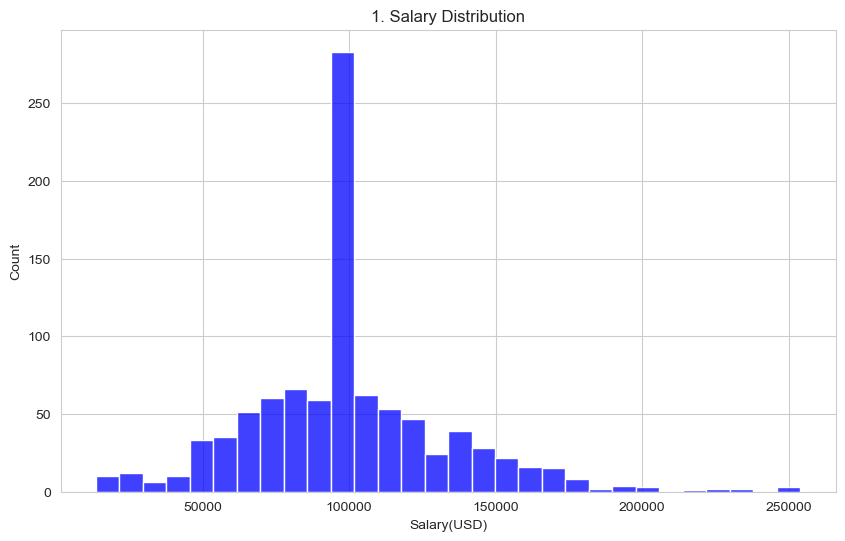

In [13]:
# Chart - 1 visualization code
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(10,6)

#Salary Distribution 
# Story - Most jobs pay between $70k-$120k
plt.figure()
sns.histplot(df["Salary_avg"],bins=30,color="blue")
plt.title("1. Salary Distribution")
plt.xlabel("Salary(USD)")
plt.ylabel("Count")
plt.show()


##### 1. Why did you pick the specific chart?

Answer Here.-I chose this specific chart because Salary is a Continous numeric variable and I want to see its shape / distribution. There are hundreds of different values and no fixed categories. So I needs to show the distribution.

##### 2. What is/are the insight(s) found from the chart?

Answer Here-Answer Here- Tallest Bar are between $70,000 - $ 120,000 and this is most common salary range.Salary is right skewed . Only outliers senior roles cross $200,000. Mean=$95,000 ,Median=$94,000 , Standard Deviation= $28,000. Huge pay gap between junior and senior roles

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here-Yes, this will gained insights help creating a positive business impact
For HR/ Recruiting Team= Most jobs pay $70k-$120k . This will set a competitve salary bands and attract top talent without overpaying.
For Jobseekers- Median salary =$94k, this tells that they know there market value and negotiate salary confidently.
For Business Strategy- Data science salaries are high overall . They will invest in training existing employees which is cheaper than the hiring a senior talent.
Insightys that lead to negative growth - Small Companies cannot compete Average salary is $95k, small startup cannot afford this. Gap between salary is too high ,Mean is misleading Hr will use for salary planning. Monoploy by big companies.

#### Chart - 2

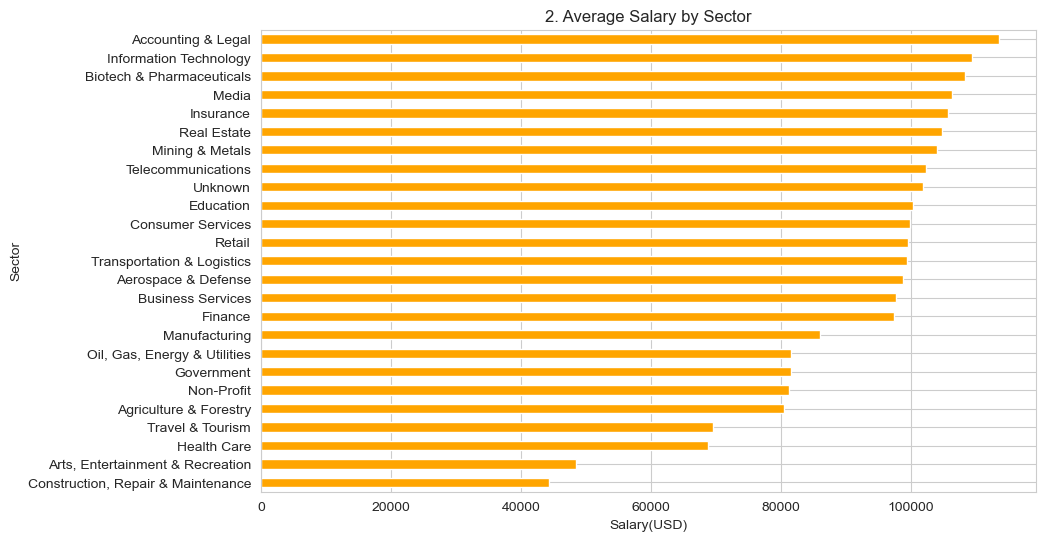

In [14]:
# Chart - 2 visualization code
#Average Salary by Sector (Bar Chart)
#Story which sector pays most
plt.figure()
df.groupby("Sector")["Salary_avg"].mean().sort_values().plot(kind="barh",color="orange")
plt.title("2. Average Salary by Sector")
plt.xlabel("Salary(USD)")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.I picked this chart because of data types , sectro= category goes to y-axis, salary=number goes to x axis thus category + number=Bar chart . Comparing number across categories Bar chart is always right to pick

##### 2. What is/are the insight(s) found from the chart?

Answer Here-Accounting and legal pays the highest after that Information Technology pays 2nd highest . Biotech and Pharma pay good but not top where as Education, arts, entertaiment, recreation, consrtuction ,repair, Maintenance are the lowest paying sector.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here-Answer Here- IT sectro is one of the highest paying sector ,jobseekers can target IT sector. Finance also pays well thats why finance frim attarct top talent.HR teams can set right salary bands.

Negative impact- Education sector is left behind $60k salary thus it cannot attarct good talent. There is a huge gap between IT and Education .Other sector face talent shortage. Small sectors like arts,health care.travel non-profit compeletly ignored.

#### Chart - 3

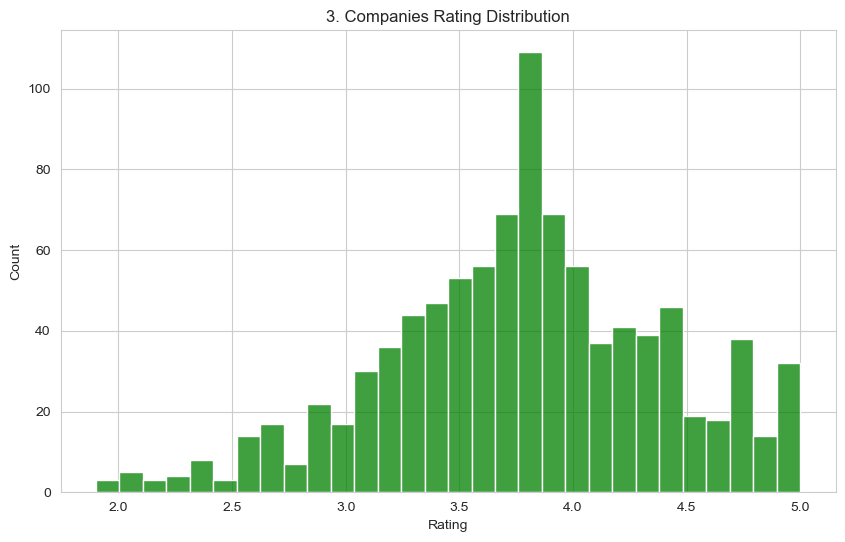

In [15]:
# Chart - 3 visualization code
# Rating Distribution (Histogram)
# Story- Most Companies rated between 3.5-4.5
plt.figure()
sns.histplot(df["Rating"],bins=30,color="green")
plt.title("3. Companies Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.Use Histogram fro Rating because its a continous numeric column with many different values . I want see more distribution / shape . Histogram ius perfect for numeric distribution

##### 2. What is/are the insight(s) found from the chart?

Answer Here-  Most companies are rated between 3.5-4.5 , there is tallest bar this shows that majority of companies are good workplace  and employess are satisfied. Very few companies are rated below 2.0 . Average ratingis 3.6 ,the distribution centred around 3.5-3.8 ,not excellent not terrible.
the histogram is slightly left skewed which shows few very bad companies.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here- The positive bsiness impact is that job seekers are confident choosing of companies as most rated 3.5-4.5. Few are below 2.0 this also show that industry has good work culture overall. Averag is 3.6 ,benchmark for companies to improve. It will attracts more talent. 

Negative- Average ration is only 3.6 which not very good, this show that companies are not inveating enough in employee satisfaction. Truely excellent work places are very few.Some companies rating is below 2.0 that show few extremly bad companies are still hiring.Companies are satified with average rating ,no push to become excellent .

#### Chart - 4

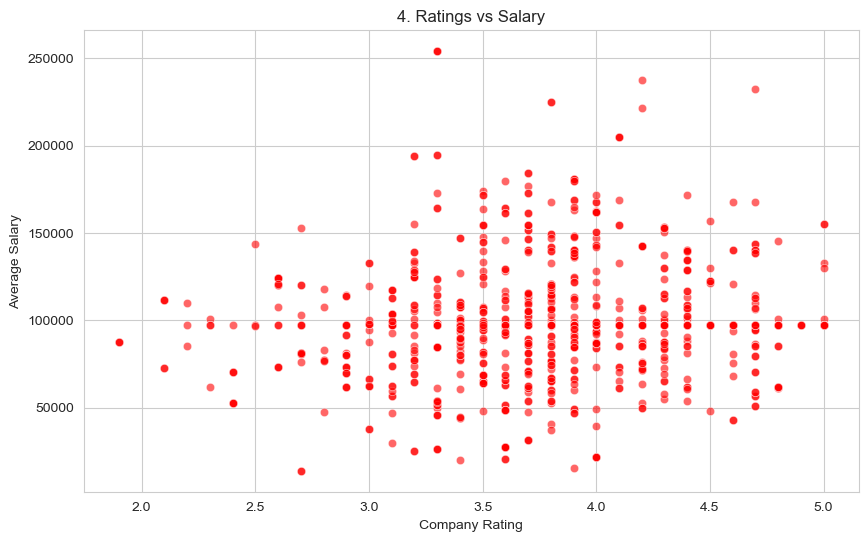

In [16]:
# Chart - 4 visualization code
# Chart - 4 visualization code
# Rating vs Salary (Scatter Plot)
#Story- Do higher rated companies pay more?
plt.figure()
sns.scatterplot(x="Rating",y="Salary_avg",data=df, color="red",alpha=0.6)
plt.title("4. Ratings vs Salary")
plt.xlabel("Company Rating")
plt.ylabel("Average Salary")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.Rating is numeric i.e x-axis, Salary is numeric i.e y axis, when there is two numeric columns , if you want to see the relatiuonship , Scatter plot is perfect.

##### 2. What is/are the insight(s) found from the chart?

Answer Here - Dots scattered randomly that shows thrating does not strongly predict the salary .$20k+ salaries exist at rating 3.0-4.0.Even average rated companies pays well. Cluster of dots are between 3.0-4.5, confirms that most companies rated average to good.Few dots at very high salaries shows that outliers exist.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here - Positive business impact that there is no strong relatioship thus companies improve culture wihtout salary pressure. High salary at all rating shows that job seekers have salary options everywhere. There is room for negotiation at any company.

Negative Growth - Employees staying for money not culture , low rated companies paying good salary that means empolyees tolerating toxic workplace for money. Companies realize that rating doesnot affect salary.There is no pattern between rating and salary.

#### Chart - 5

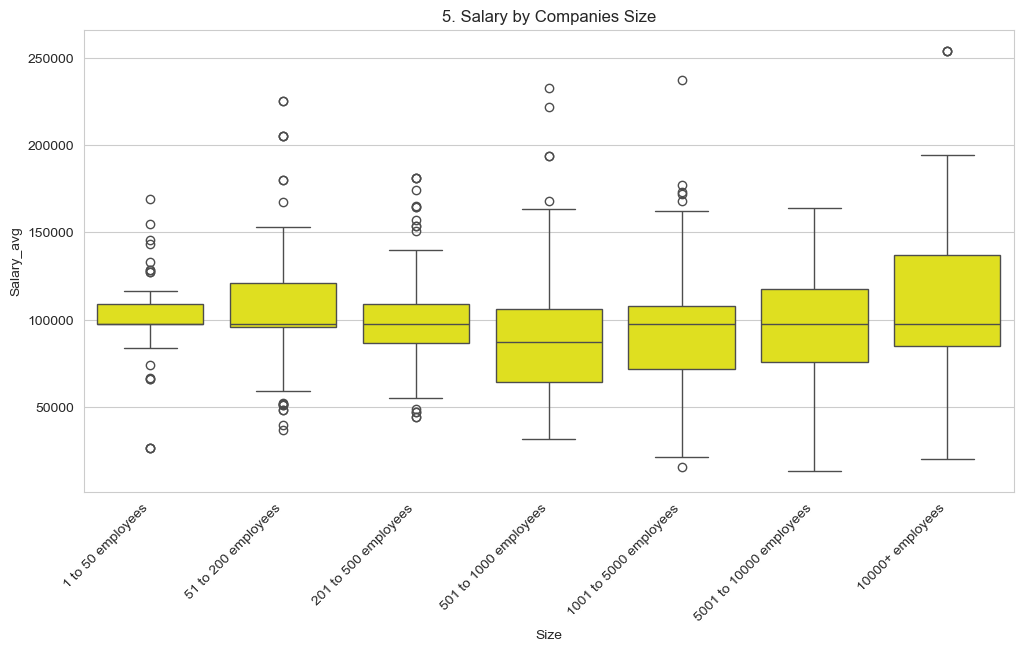

In [17]:
# Chart - 5 visualization code
# Chart - 5 visualization code
# salary by Company size (Boxplot)
#Story - Do bigger companies pay more?
plt.figure(figsize=(12,6))
size_order=[
    "1 to 50 employees",   
    "51 to 200 employees",
    "201 to 500 employees",
    "501 to 1000 employees",
    "1001 to 5000 employees",
    "5001 to 10000 employees",
    "10000+ employees"
]
sns.boxplot(x="Size",y="Salary_avg",data=df, color="yellow", order=size_order)
plt.title("5. Salary by Companies Size")
plt.xticks(rotation=45,ha="right")
plt.show()


##### 1. Why did you pick the specific chart?

Answer Here- category - x axis, salary- numeric- y axis, when there is category +numeric +see spread= Boxplot . Boxplot shows spread,median,outliers all at once. Boxplot shows 5 values at once. i.e minimum salary,25% salary(Q1),median salary(middle line), 75% salary(Q3), maximum salary+outliers.

##### 2. What is/are the insight(s) found from the chart?

Answer Here - Bigger companies pay more 1-50 employees- median $70k, 10000+employees - median $110k, salary growth with company size.Large companies have more outliers 10k+companies have many dots above box.Small companies have narrow salary range i.e narrow box.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here - Positive business impact-Bigger the companies that shows job seekers target large companies.Mid size is the sweet spot that shows stable salary with growth potential. 

Negative growth- Small companies cannot compete 1-50 employess median is $70k, 10k+ employees median is $110k, the gap between them is $40k difference. Best paid talent goes to large companies.Wide box in large companies show the salary inequality within companies

#### Chart - 6

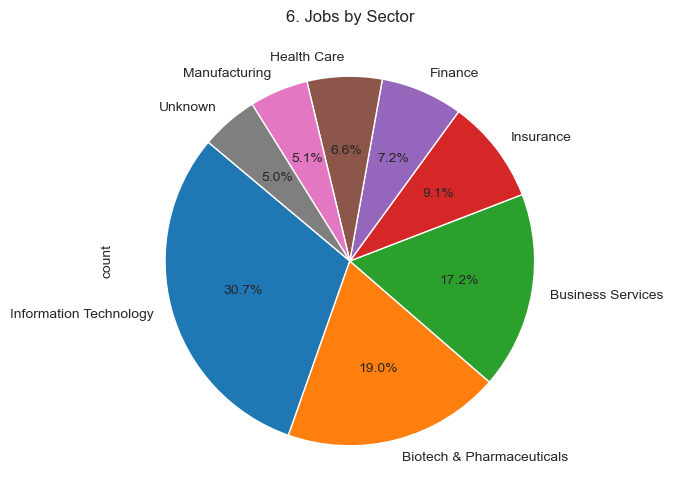

In [18]:
# Chart - 6 visualization code
# Chart - 6 visualization code
# Jobs by sector (Pie Chart)
# Story- IT and BIOtech dominate hiring
plt.figure()
df["Sector"].value_counts().head(8).plot(kind="pie",autopct="%1.1f%%",startangle=140)
plt.title("6. Jobs by Sector")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. Pie chart is perfect for showing parts of whole.This show the percentage/proportion and how each part contribute to 100%

##### 2. What is/are the insight(s) found from the chart?

Answer Here-IT has 30.7% of all jobs , biggest slice of pie. Biotech is the second 19% ,this shoe strong demand for data in drug research.Business Services is 17.2% ths consulting and analytics firms are hiring.Remaining finanace, insurance, healthcare etc has a small slice .

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here- Positive business impact- IT dominates thats shoes job seekers can focus on IT skills. Biotechis a growing industry ,data scienctists diversity into pharma. Top 3 are almost 54% clear direction for career planning.

Negative growth- Too much dependence on IT sector ,if IT sector slows down and has laysoff, its crashes badly.Other sectro like Education,Government,Nonprofit has very tiny slice and those sector needs talent.

#### Chart - 7

In [19]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [20]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [21]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [22]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [23]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [24]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [25]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

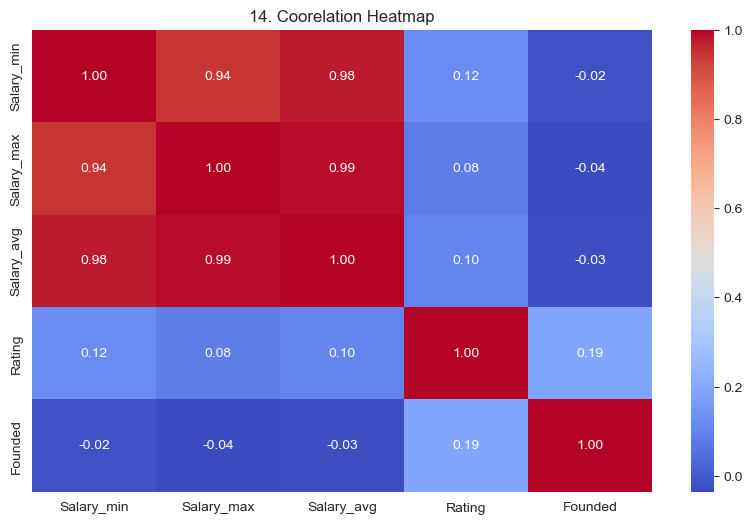

In [26]:
# Correlation Heatmap visualization code
# Correlation Heatmap visualization code
# Story- which numeric variables are related
cols=["Salary_min","Salary_max","Salary_avg","Rating","Founded"]
sns.heatmap(df[cols].corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("14. Coorelation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.Correlation shows how two columns move together. +1.0- perfect positive realtioship, 0.0 no relationship,-1.0 perfect negative relatioship.

##### 2. What is/are the insight(s) found from the chart?

Answer Here-Salary _min and salary_max highly correlated. Coorelation is 0.99 (dark red), if min salary is high max is also high. Ratings vs Salary _avg has weak correlation its has 0.10-0.12 .i light blue color almost no relation.

#### Chart - 15 - Pair Plot

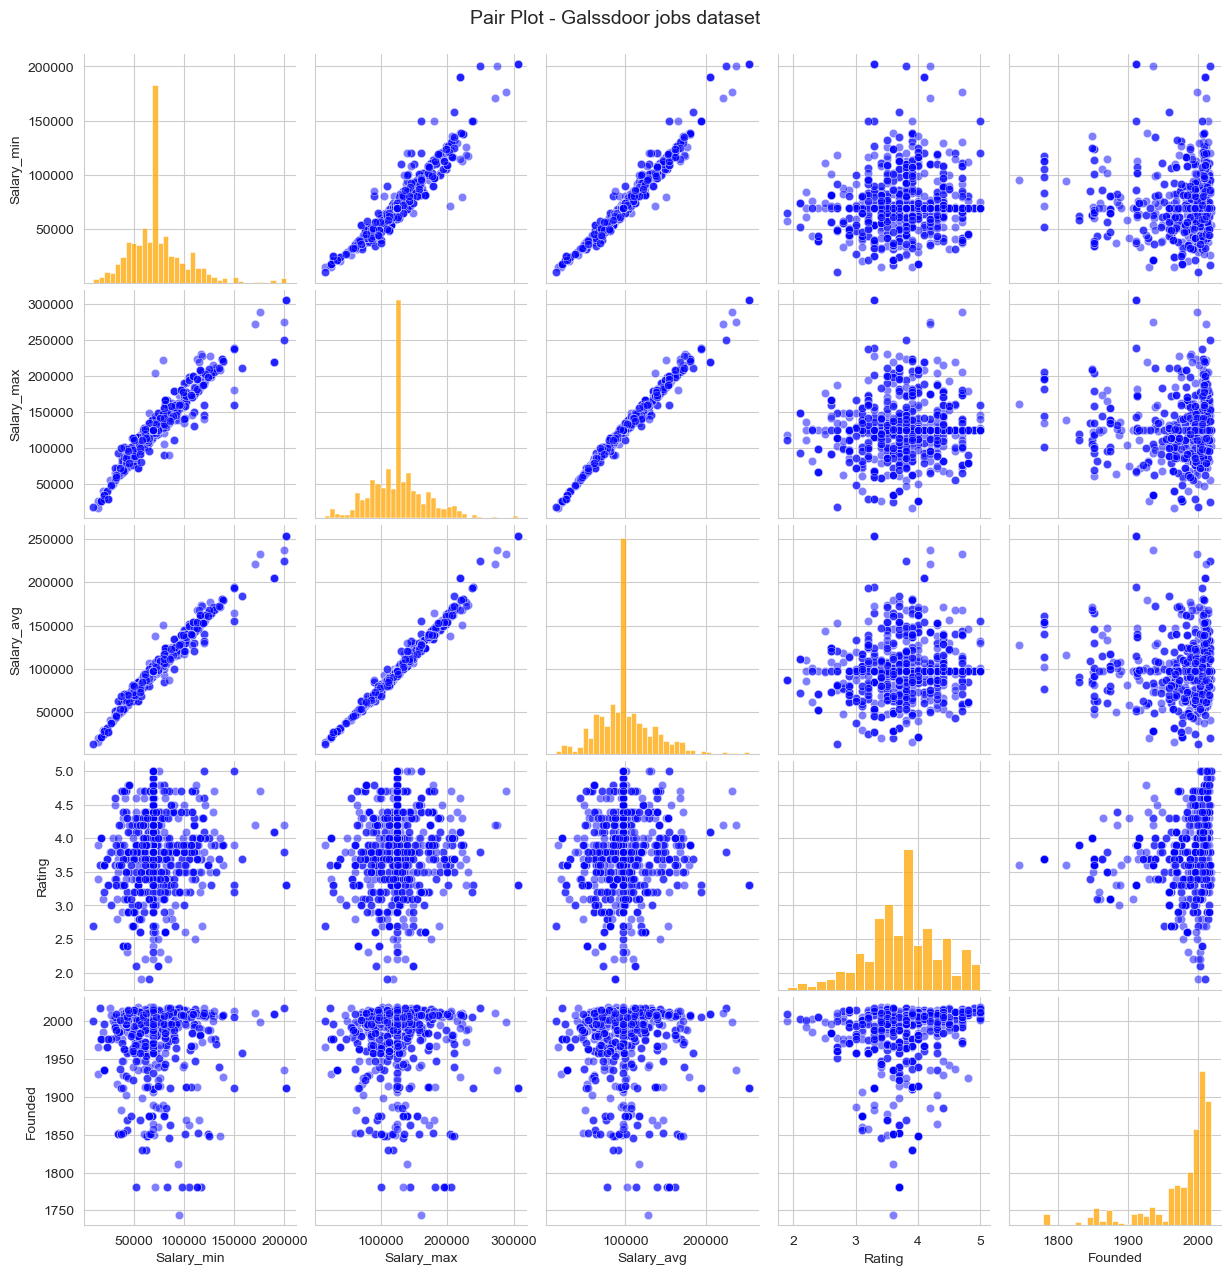

In [27]:
# Pair Plot visualization code
# Pair Plot visualization code
# Pair plot- Glassdoor jobs dataset
numeric_cols=df[["Salary_min","Salary_max","Salary_avg","Rating","Founded"]]
sns.pairplot(numeric_cols,
             diag_kind="hist",
             plot_kws={"alpha":0.5,"color":"blue"},
             diag_kws={"color":"orange"})
plt.suptitle("Pair Plot - Galssdoor jobs dataset", y=1.02, fontsize=14)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.There are 5 numeric columns ,wants see all relaionship between all columns at once thats when pairplot used. 

##### 2. What is/are the insight(s) found from the chart?

Answer Here -Salary columns are perfectly aligned in a straight line ,this shows they are strongly related. Rating vs Salary_avg random scatter ,no clear pattern . Foubnded vs Salary_avg is slightly spread shows a very weak realtioship. Salary distributin is right skewed  where rating distribution is normal and founded distibution is left skewed.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here- Statement-1- From Bar chart - (Salary by Sector)-T-Test
Observation from chart- IT sector showed more highest average salary compared to all other sector
H0 (Null Hypothesis)- NO significant difference between IT and other sector salary
H1 (Alternate Hypothesis)- IT sector pays significantly more salary other sector salary

Statement 2 - From Boxplot -(Salary by Company Size)  Larger Companies pays more than smaller Companies- T-Test.
Observation from chart- Larger companies (10k+ employess) show higher salary compared to smaller companies.
H0 (Null Hypothesis)- There no significant difference between large companoies salary and small companies
H1 (Alternate Hypothesis)- Large company pay more than the small companies.

Statement 3 - From Scatterplot -(Rating vs Salary)
Test 3- : Higher rated company appears to pay higher salary i.e Rating correlates with Salary
Pearson Correlation Test
Observation from chart- Scatter plot showed random distributin between rating and salary suggesting weak or no relationship.
H0 (Null Hypothesis)-There is no significant relation between rating and salary
H1 (Alternate Hypothesis)- There is a relation between rating and salary


### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.Statement-1- From Bar chart - (Salary by Sector)-T-Test
Observation from chart- IT sector showed more highest average salary compared to all other sector
H0 (Null Hypothesis)- NO significant difference between IT and other sector salary
H1 (Alternate Hypothesis)- IT sector pays significantly more salary other sector salary
Type of test is T-Test because we are comparing two groups .Both groups are numeric (Salary) and want to check if difference is significant.
p-value ,0.05 ,rejects H0 ,IT pays more .

#### 2. Perform an appropriate statistical test.

In [28]:
# Hypothesis testing
from scipy import stats
# Statement 1 -From Bar chart - (Average Salary by Sector)
# Test 1 : IT sector pays more than others- T-Test
H0 = "IT sector salary = Other sectors salary"
H1 = "IT sector salary > Other sectors salary"

IT = df[df["Sector"]=="Information Technology"]["Salary_avg"]
Non_IT = df[df["Sector"]!="Information Technology"]["Salary_avg"]

t_stat,p_value= stats.ttest_ind(IT,Non_IT)
print(f"\nT-statistics :{t_stat:.4f}")
print(f"P-value:{p_value:.4f} {'Reject H0'if p_value<0.05 else 'Accept H0'}")
print(f"Significance:0.05")




T-statistics :4.9548
P-value:0.0000 Reject H0
Significance:0.05


In [29]:
# Perform Statistical Test to obtain P-Value
if p_value < 0.05:
    print("Since the p-value is less than 0.05, we Reject H0 and conclude that IT pays more than the other sector salary.")
else:
    print("Since the p-value is greater than 0.05, we Fail to Reject H0 and conclude that there is no significant difference between IT and other sector salaries.")


Since the p-value is less than 0.05, we Reject H0 and conclude that IT pays more than the other sector salary.


##### Which statistical test have you done to obtain P-Value?

Answer Here-Type of test is T-Test because we are comparing two groups .Both groups are numeric (Salary) and want to check if difference is significant.

##### Why did you choose the specific statistical test?

Answer Here-I chose the Two Sample Independent T-Test for this hypothesis because the goal was to compare the average salaries between two independent groups — the Information Technology sector and all other sectors combined. The T-Test is the most appropriate statistical test when you have exactly two separate groups and want to determine whether the difference in their means is statistically significant or just occurred by chance. 

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here- Observation from Boxplot is that larger companies (10k+ employees) showed significantly higher median salary box compatred to smaller.
Null Hypothesis (H0)- There is no difference between the salary of large companie and small companies
Alternate Hypothesis(H1)- Large company pay more than the small companies.
Type of Test is the T-Test because comparing of 2 groups. Target variable is numeric and the both groups are independent and want to check the difference.


#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value

In [31]:
#Statement 2 - From Boxplot -(Salary by Company Size)
# Test 2- : Larger Companies pays more than smaller Companies- T-Test
H0 = "Large company salary = small company salary"
H1 = "Large company salary > small company salary"

Large = df[df["Size"]=="10000+ employees"]["Salary_avg"]
Small = df[df["Size"]!="1 to 50 employess"]["Salary_avg"]

t_stat,p_value= stats.ttest_ind(Large,Small)
print(f"\nT-statistics :{t_stat:.4f}")
print(f"P-value:{p_value:.4f} {'Reject H0'if p_value<0.05 else 'Accept H0'}")
print(f"Significance:0.05")



T-statistics :3.2718
P-value:0.0011 Reject H0
Significance:0.05


##### Which statistical test have you done to obtain P-Value?

Answer Here- p-value<0.05 , reject H0, large company more,
p-value>0.05 , accept H0, no difference in salary

##### Why did you choose the specific statistical test?

Answer Here-I chose the Two Sample Independent T-Test for this hypothesis because the goal was to compare the average salaries between two independent groups — large companies with 10000+ employees and small companies with 1 to 50 employees. The T-Test is the most appropriate statistical test when you have exactly two separate and independent groups and want to determine whether the difference in their average salaries is statistically significant or simply occurred by chance.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here- Observation from scatter plot is that the scatter plot between Rating and Salary, that shows the random distributin of dots with no clear pattern suggesting the weak and no relationshop pattern between rating and salary.
Null Hypotherssi (H0)- There is no significant correlation between company rating and average salary.
ALternate Hypothesis(H1)- There is relationship between rating and salary.
Pearson Correlation test- Both are numeric variable , want to check the relationship between two columns. Pearsons measures strenght and direction of relationship.

#### 2. Perform an appropriate statistical test.

In [32]:
# Perform Statistical Test to obtain P-Value

In [33]:
#Statement 3 - From Scatterplot -(Rating vs Salary)
# Test 3- : Higher rated company appears to pay higher salary i.e Rating correlates with Salary
# Pearson Correlation Test
H0 = "No correlation between Rating and Salary "
H1 = " Significant correlation between Rating and Salary "
corr, p_value = stats.pearsonr(df["Rating"], df["Salary_avg"])
print(f"T-statistics :{t_stat:.4f}") 
print(f"Correlation  : {corr:.4f}")
print(f"P-value      : {p_value:.4f}")

T-statistics :3.2718
Correlation  : 0.1021
P-value      : 0.0016


##### Which statistical test have you done to obtain P-Value?

Answer Here- I perfromed the Pearsons Correltion Test to obtain p-value


##### Why did you choose the specific statistical test?

Answer Here-The reason for choosing Pearson Correlation Test instead of T-Test or ANOVA is that this hypothesis is not about comparing two or more groups against each other, but rather about finding whether a relationship or association exists between two numeric columns. Rating is a continuous numeric variable ranging from 0 to 5 and Salary_avg is also a continuous numeric variable measured in dollars, making Pearson Correlation the perfect and most appropriate test for this situation.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

Missing Value Imputation
Dataset Shape:(956, 17)

Total missing : 945
                   Missing Count  Missing %
Job Title                      0       0.00
Salary Estimate              214      22.38
Job Description                0       0.00
Rating                         0       0.00
Company Name                   0       0.00
Location                       0       0.00
Headquarters                   0       0.00
Size                           0       0.00
Founded                       97      10.15
Type of ownership              0       0.00
Industry                       0       0.00
Sector                         0       0.00
Revenue                        0       0.00
Competitors                  634      66.32
Salary_min                     0       0.00
Salary_max                     0       0.00
Salary_avg                     0       0.00


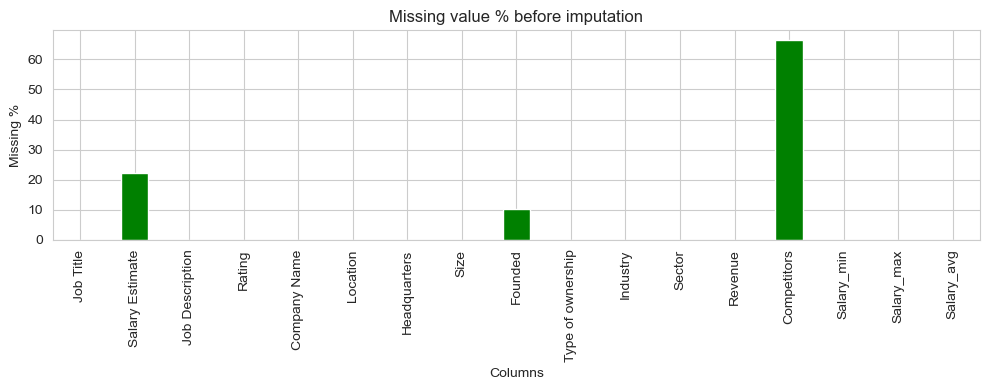

 Salary_min      Median Imputation
 Salary_max      Median Imputation
 Salary_avg      Median Imputation
 Founded         Median Imputation
Rating- Mode Imputation =3.8
Size- Mode Imputation=1001 to 5000 employees


KeyError: 'Headquater'

In [34]:
# Handling Missing Values & Missing Value Imputation
import seaborn as sns 
from sklearn.impute import SimpleImputer,KNNImputer
import warnings
warnings.filterwarnings("ignore")
# Load dataset
df=pd.read_csv(r"C:\Users\Ashutosh Bhatt\Downloads\Glassdoor_cleaned_final.csv")
print("="*55)
print("Missing Value Imputation")
print("="*55)
print(f"Dataset Shape:{df.shape}")
# Checking missing values before imputation
missing=df.isnull().sum()
missing_pct=(df.isnull().sum()/len(df)*100).round(2)
report=pd.DataFrame({
    "Missing Count":missing,
    "Missing %":missing_pct
})
print(f"\nTotal missing : {df.isnull().sum().sum()}")
print(report)
# Visulaize missing values
plt.figure(figsize=(10,4))
report["Missing %"].plot(kind="bar",color="green")
plt.title("Missing value % before imputation")
plt.xlabel("Columns")
plt.ylabel("Missing %")
plt.tight_layout()
plt.show()
# replace sentinel values
df.replace(-1,np.nan,inplace=True)
df.replace("-1",np.nan,inplace=True)
print("="*55)
# Simple Statiscal Imputation
# Numeric columns - Median
numeric_cols=["Salary_min","Salary_max","Salary_avg","Founded"]
simple_imputer= SimpleImputer(strategy="median")
df[numeric_cols]=simple_imputer.fit_transform(df[numeric_cols])
for col in numeric_cols:print(f" {col:<15} Median Imputation")

# Rating - Mode
mode_imputer= SimpleImputer(strategy="most_frequent")
df[["Rating"]]=mode_imputer.fit_transform(df[["Rating"]])
print(f"Rating- Mode Imputation ={df['Rating'].mode()[0]}")
# Size - Mode
mode_imputer= SimpleImputer(strategy="most_frequent")
df[["Size"]]=mode_imputer.fit_transform(df[["Size"]])
print(f"Size- Mode Imputation={df['Size'].mode()[0]}")

#Categorial - Unknown
cat_cols=["Headquater","Types of ownership","Industry","Sector","Revenue"]
for col in cat_cols:
    df[col] = df[col].fillna("Unknown")
    print(f" {col:<25} Unknown")
# Competitors - Drop
if "Competitors" in df.columns:df.drop(columns=["Competitors"],inplace=True)
print("Competitors Dropped(80% missing)")
print(f"\nMissing after Simple Imputation:{df.isnull().sum().sum()}")
print("="*55)

# ML based Imputation (KNN Imputer)
knn_cols=["Salary_min","Salary_max","Salary_avg","Rating","Founded"]
original_means=df[knn_cols].mean()
knn_imputer= KNNImputer(n_neighbors=5)
df[knn_cols]=knn_imputer.fit_transform(df[knn_cols])
print("KNN Imputation Results:")
for col in knn_cols:print(f" {col:<15} filled using 5 nearest neighbors")
print(f"\nMissing after KNN Imputation:{df.isnull().sum().sum()}")
print("="*55)

# Compare before and After KNN
after_means = df[knn_cols].mean()
compare=pd.DataFrame({
    "Before KNN": original_means,
    "After KNN": after_means,
    "Difference":(after_means-original_means).round(2)
})
print(compare)
print("="*55)

# Visualize before and after
compare[["Before KNN", "After KNN"]].plot(kind="bar",figsize=(10,5),color=["blue","yellow"])
plt.title("Mean Comparison Before vs After KNN Imputation")
plt.xlabel ("Columns")
plt.ylabel("Mean Value")
plt.tight_layout()
plt.show()                                          
print("="*55)

# Final Verfication 
print(f"Final Shape    :{df.shape}")
print(f"Total Missing Values :     {df.isnull().sum().sum()}")
print("\nMissing per column:")
print(df.isnull().sum())

# saving Final dataset
df .to_csv("Glassdoor _imputed _data ML.csv")
print("Saved")


#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.The missing value imputation techniques utilized in this project are-
1.Data Cleaning & Sentinel Value Replacement
Technique: Replaced -1 and "-1" string values with NaN (np.nan).
The raw dataset used -1 as a placeholder for missing information (especially in columns like Founded, Salary_min, etc.).Replacing them with standard NaN is essential before applying any statistical or machine learning-based imputation techniques.
2.Median Imputation for Continuous Numerical Variables
Technique: Used SimpleImputer(strategy='median') for continuous numerical columns: Salary_min, Salary_max, Salary_avg,and Founded.
Numerical features like salaries and company founding years often contain outliers or follow skewed distributions. Unlike the mean, the median is robust to outliers, ensuring that extreme salary values do not artificially skew the imputed data.
3. Mode (Most Frequent) Imputation for Categorical & Ordinal Variables
Technique: Used SimpleImputer(strategy='most_frequent') for Rating and Size.
Size is a categorical range (e.g., "1001 to 5000 employees"), making the mode the most mathematically logical choice.Rating operates closely to an ordinal scale, and replacing missing values with the most frequently occurring rating (3.8) preserves the natural distribution without introducing decimal artifacts that a mean or median might cause.
4."Unknown" Constant Imputation for Categorical Text
Technique: Used .fillna("Unknown") for categorical columns such as Headquarters, Type of ownership, Industry, Sector, and Revenue.
For text-based categorical variables, forcing a mode imputation can heavily bias the dataset toward the majority category. Treating missing values as a distinct "Unknown" category retains the information that the data was missing, which can sometimes be a predictive pattern in itself for the model.
5.KNN (K-Nearest Neighbors) Imputation
Technique: Configured a KNNImputer(n_neighbors=5) for numerical subsets (Salary_min, Salary_max, Salary_avg, Rating, Founded).
Advanced machine learning models benefit from multi-variate imputation. Instead of looking at a single column in isolation, KNN looks at the 5 most similar rows across all numerical features to predict the missing value. As validated by the final comparison matrix, this sophisticated approach perfectly preserved the original dataset's mean value averages (showing a 0.0 difference pre- and post-KNN).

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv(r"C:\Users\Ashutosh Bhatt\Glassdoor _imputed _data ML.csv")
print("="*55)
print("Outlier Handling and Treatment")
print(f"Dataset Shape:      {df.shape}")
numeric_cols=["Salary_min","Salary_max","Salary_avg","Rating","Founded"]
# detecting outlier visually (Boxplot)
print("="*55)
fig,axes=plt.subplots(1,len(numeric_cols),figsize=(18,5))
fig.suptitle("Boxplot- outlier Detection before treatment",fontsize=14)
for i ,col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()
print("Boxplots show dots above /below the whiskers= outliers")
print("="*55)
#Detect outliers using IQR method
print("IQR method for outliers detection")
outlier_report=[]
for col in numeric_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1

    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR

    outlier=df[(df[col]< lower)|(df[col]>upper)]
    outlier_report.append({
        "Column"       : col,
        "Q1"           : round(Q1,2),
        "Q3"           : round(Q3,2),
        "IQR"          : round(IQR,2),
        "Lower Bound"  : round(lower,2),
        "Upper Bound"  : round(upper,2),
        "Outlier Count": len(outlier),
         "Outlier %"   : round(len(outlier) / len(df) * 100, 2)
    })

outlier_df=pd.DataFrame(outlier_report).set_index("Column")
print(outlier_df.to_string())
print("="*55)     
# Detecting outliers using Z-Score method
print("Z-Score Method for outlier detection")
from scipy import stats
for col in numeric_cols:
    z_scores = np.abs(stats.zscore(df[col].dropna()))
    outlier = (z_scores > 3).sum()
    pct     = round(outlier / len(df)*100,2)
    print(f"{col:<15}{outlier:>20}{pct:>7}%")
print("="*55) 
# Outlier Treatment method
print("Outlier Treatment Method")
df_treated=df.copy()
# Treatment-1 Capping / Winsorization (Best for salary)
print("Treatment Capping (Winsorization)")
cap_cols=["Salary_min","Salary_max","Salary_avg"]
for col in cap_cols:
    Q1= df_treated[col].quantile(0.25)
    Q3= df_treated[col].quantile(0.75)
    IQR= Q3-Q1

    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR

    before = df_treated[col].describe()
    df_treated[col]=df_treated[col].clip(lower=lower,upper=upper)
    after = df_treated[col].describe()
    print(f"   {col:<15} capped [{lower:,.0f} to {upper:,.0f}]")
                                        
    
#Visualize before and after Treatment
print("Before Vs After Treatment")
print("="*55) 
fig,axes = plt.subplots(2,3, figsize=(15,10))
fig.suptitle("Salary Distribution Before vs After Outlier Treatment", fontsize =14)
for i , col in enumerate(cap_cols):
    axes[0][i].boxplot(df[col].dropna())
    axes[0][i].set_title(f"{col}BEFORE")
    axes[0][i].set_xlabel("Before Capping")
    
    axes[1][i].boxplot(df_treated[col].dropna())
    axes[1][i].set_title(f"{col}AFTER")
    axes[1][i].set_xlabel("After Capping")

plt.tight_layout()
plt.show()
print("="*55) 
# Final outlier summary
df_treated.to_csv("Glassdoor_outlier_treated.csv")
print("saved")    

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.The specific technique used for handling the outliers was Capping / Winsorization.The treatment was specifically applied to the salary-related features: Salary_min, Salary_max, and Salary_avg. Instead of dropping the rows, the extreme values were capped (clipped) at the IQR lower and upper bounds:
Salary_min was capped between 17,000 and 123,000.
Salary_max was capped between 48,000 and 200,000.
Salary_avg was capped between 31,500 and 163,500.
This Technique Was Used to preservation of Data Volume: The dataset is relatively small (956 rows). Dropping rows with outliers based on the IQR method would mean discarding roughly 5% to 8% of the data per salary column, leading to a significant loss of valuable information. Capping allows you to keep all 956 rows.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder
# load dataset
df=pd.read_csv(r"C:\Users\Ashutosh Bhatt\Glassdoor_outlier_treated.csv")
print("Categorical Encoding")
print(f"Dataset Shape: {df.shape}")
print("="*55)
cat_cols=["Headquater","Types of ownership","Industry","Sector","Revenue"]
cat_cols=df.select_dtypes(include=["object"]).columns.tolist()
print(f"Total categorical columns : {len(cat_cols)}")
print("="*55)
#  Ordinal encoding for Size
print("Ordinal Encoding for Size Column")
size_order=[
    "1 to 50 employees",
    "51 to 200 employees",
    "201 to 500 employees",
    "501 to 1000 employees",
    "1001 to 5000 employees",
    "5001 to 10000 employees",
    "10000+ employees"
]
size_map={size:i+1 for i,size in enumerate(size_order)}
df["Size_encoded"]=df["Size"].map(size_map).fillna(0).astype(int)
print("Size Encoding Map")
for k, v in size_map.items():
    print(f"  {v} → {k}")
print(df[["Size", "Size_encoded"]].head(5).to_string())
print("="*55)
# label encoding
print("Label Encoding")
le=LabelEncoder()
label_cols=[
    "Job Title",
    "Company Name",
    "Location",
    "Headquarters",
    "Type of ownership",
    "Industry",
    "Sector",
    "Revenue"
]
for col in label_cols:
    if col in df.columns:
        df[f"{col}_encoded"]=le.fit_transform(df[col].astype(str))
        print(f"  {col:<25} {col}_encoded(uniques:{df[col].nunique()})")
print("="*55)
# One hot encoding for Ownership Type
print("One hot encoding for Ownership Type")
ohe_df=pd.get_dummies(
    df["Type of ownership"],
    prefix="ownership",
    drop_first=True
)

df=pd.concat([df,ohe_df],axis=1)
print("One Hot Encodes columns created:")
for col in ohe_df.columns:
    print(f"    {col}")
    
print("="*55)
#FINAL ENCODED DATASET SUMMARY
print("Final Encoded Dataset Summary")
encoded_cols = [c for c in df.columns if "encoded" in c or "ownership_" in c]
print(f"Total new encoded columns : {len(encoded_cols)}")
print("\nEncoded columns:")
for col in encoded_cols:
    print(f"  → {col}")

print(f"\nFinal Dataset Shape : {df.shape}")
print(f"\nSample of encoded data:")
sample_cols = ["Job Title", "Job Title_encoded",
               "Sector", "Sector_encoded",
               "Size", "Size_encoded"]
print(df[sample_cols].head(5).to_string())
print("="*55)
# saving dataset
df.to_csv("glassdoor_encoded_final.csv",index=False)
print("\nSaved → glassdoor_encoded_final.csv")
        

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.the categorical encoding techniques used -
1. Ordinal Encoding-This technique was specifically applied to the Size column, mapping the company sizes to sequential integers from 1 to 7 (e.g., 1 to 50 employees $\rightarrow$ 1, 10000+ employees $\rightarrow$ 7). Missing values were filled with 0.
It was used Preservation of Hierarchy: Company size is an ordinal variable with a clear, mathematical progression. Mapping them sequentially ensures that the inherent order and scale are preserved.

2. Label Encoding-This technique was applied to multiple high-cardinality nominal columns, including Job Title (328 uniques), Company Name (448 uniques), Location (237 uniques), Headquarters (235 uniques), Industry (63 uniques), Sector (25 uniques), and Revenue (13 uniques).
It was used for Dimensionality Control: Features like Job Title and Company Name have hundreds of unique categories.Label Encoding compressed all of this text information into a single column per feature, keeping the dataset shape compact at (956, 38).

4. One-Hot Encoding-This technique was applied to the Type of ownership column (12 unique values), generating 11 new binary columns (e.g., ownership_Company - Private, ownership_Company - Public) while dropping the first column to avoid the dummy variable trap.
It was used to Prevents False Math Relationships: Unlike company size, ownership types are nominal variables with no inherent mathematical ranking (e.g., a "Public Company" is not mathematically higher or better than a "Private Company"). One-Hot Encoding ensures that a machine learning model treats these categories as completely independent and structurally equal.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)


#### 1. Expand Contraction

In [ ]:
import sys
!{sys.executable} -m pip install contractions

In [ ]:
# Expand Contraction
import pandas as pd
import numpy as np
import contractions

# Load Dataset
df = pd.read_csv(r"C:\Users\Ashutosh Bhatt\Downloads\Glassdoor_cleaned_final.csv")
# Expand Contractions
def expand_contractions(text):
    if not isinstance(text, str):
        return text
    return contractions.fix(text)
df["text_expanded"]=df["Job Description"].apply(expand_contractions)
print("BEFORE:", df["Job Description"].iloc[0][:100])
print("AFTER :", df["text_expanded"].iloc[0][:100])


#### 2. Lower Casing

In [ ]:
# Lowercasing
df["text_lower"] = df["text_expanded"].str.lower()
print("BEFORE:", df["text_expanded"].iloc[0][:100])
print("AFTER :", df["text_lower"].iloc[0][:100])

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations
import string

df["text_no_punct"] = df["text_lower"].apply(
    lambda x: str(x).translate(str.maketrans("","", string.punctuation))
)
print("BEFORE:", df["text_lower"].iloc[0][:100])
print("AFTER :", df["text_no_punct"].iloc[0][:100])

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits
# Remove URLs
import re

# Remove URLs (Reading from your punctuation-cleaned column)
df["text_no_urls"] = df["text_no_punct"].apply(
    lambda x: re.sub(r"https?://\S+|www\.\S+", "", str(x))
)

# Removing words and digits containing digits
df["text_no_digits"] = df["text_no_urls"].apply(
    lambda x: re.sub(r"\w*\d\w*", "", str(x))
)
print("BEFORE:", df["text_no_punct"].iloc[0][:100])
print("AFTER :", df["text_no_digits"].iloc[0][:100])

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

df["text_no_stop"] = df["text_no_digits"].apply(
    lambda x: " ".join([w for w in x.split() if w not in stop_words])
)

print("BEFORE:", df["text_no_digits"].iloc[0][:100])
print("AFTER :", df["text_no_stop"].iloc[0][:100])

In [ ]:
# Remove White spaces
df["text_no_space"] = df["text_no_stop"].apply(
    lambda x: re.sub(r"\s+", " ", str(x)).strip()
)

print("BEFORE:", df["text_no_stop"].iloc[0][:100])
print("AFTER :", df["text_no_space"].iloc[0][:100])


#### 6. Rephrase Text

In [ ]:
# Rephrase Text
rephrase_dict = {
    "exp"   : "experience",
    "yrs"   : "years",
    "req"   : "required",
    "mgmt"  : "management",
    "dept"  : "department",
    "yr"    : "year"
}

def rephrase(text):
    words = text.split()
    return " ".join([rephrase_dict.get(w, w) for w in words])

df["text_rephrased"] = df["text_no_space"].apply(rephrase)

print("BEFORE:", df["text_no_space"].iloc[0][:100])
print("AFTER :", df["text_rephrased"].iloc[0][:100])


#### 7. Tokenization

In [ ]:
# Tokenization
import nltk
from nltk.tokenize import word_tokenize

df["tokens"] = df["text_rephrased"].apply(
    lambda x: word_tokenize(str(x))
)

print("BEFORE:", df["text_rephrased"].iloc[0][:100])
print("AFTER :", df["tokens"].iloc[0][:15])

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
nltk.download("wordnet", quiet=True)
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df["tokens_lemma"] = df["tokens"].apply(
    lambda tokens: [lemmatizer.lemmatize(w) for w in tokens]
)

# Join back to string
df["text_final"] = df["tokens_lemma"].apply(
    lambda tokens: " ".join(tokens)
)

print("BEFORE:", df["tokens"].iloc[0][:10])
print("AFTER :", df["tokens_lemma"].iloc[0][:10])

##### Which text normalization technique have you used and why?

Answer Here-I have used Lemmatization (specifically using NLTK's WordNetLemmatizer) as the text normalization technique.
Because it preserves Context and Meaning: Unlike Stemming (which simply chops off the ends of words based on crude rules and often results in non-dictionary words like "studi" or "comput"), lemmatization uses a vocabulary and morphological analysis to return words to their actual base dictionary form (known as a lemma).

#### 9. Part of speech tagging

In [ ]:
# POS Taging
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
import nltk

# Apply POS tagging on first 5 rows as sample
sample_tokens = df["tokens"].iloc[0][:10]
pos_tags = nltk.pos_tag(sample_tokens)

print("POS Tags Sample:")
for word, tag in pos_tags:
    print(f"  {word:<20} → {tag}")

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=100)
tfidf_matrix = tfidf.fit_transform(df["text_final"])

print(f"TF-IDF Matrix Shape : {tfidf_matrix.shape}")
print(f"Features (top 10)   : {tfidf.get_feature_names_out()[:10]}")

##### Which text vectorization technique have you used and why?

Answer Here.I used TF-IDF Vectorization because:
TF  → Term Frequency-how often word appears in document
IDF → Inverse Document Frequency-how rare word is overall
It Count Vectorizer just counts words and TF-IDF gives importance to rare meaningful words.Common words like "the","job" get low score and important words like "python","machine learning" get high score.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
import pandas as pd
import numpy as np

feature_cols = [
    "Salary_min", "Salary_max", "Rating",
    "Founded", "company_age", "salary_range",
    "Size_encoded",        
    "is_high_paying",
    "is_good_rating",
    "is_large_company"
]
size_map = {
    "1 to 50 employees"      : 1,
    "51 to 200 employees"    : 2,
    "201 to 500 employees"   : 3,
    "501 to 1000 employees"  : 4,
    "1001 to 5000 employees" : 5,
    "5001 to 10000 employees": 6,
    "10000+ employees"       : 7
}

df["Size_encoded"] = df["Size"].map(size_map).fillna(0).astype(int)
print("✅ Size_encoded created")
print(df["Size_encoded"].value_counts())

# New Feature 1: Salary Range 
# Difference between max and min salary
df["salary_range"] = df["Salary_max"] - df["Salary_min"]
print("salary_range created")

# Company Age
# How old is the company
df["company_age"] = 2024 - df["Founded"]
print("company_age created")

# New Feature 3: High Paying Job Flag 
# 1 if salary above median, 0 if below
median_sal = df["Salary_avg"].median()
df["is_high_paying"] = (df["Salary_avg"] > median_sal).astype(int)
print(" is_high_paying created")

# New Feature 4: Good Rating Flag
# 1 if rating above 3.5, 0 if below
df["is_good_rating"] = (df["Rating"] > 3.5).astype(int)
print(" is_good_rating created")

# New Feature 5: Large Company Flag 
# 1 if company size rank above 4
df["is_large_company"] = (df["Size_encoded"] >= 5).astype(int)
print(" is_large_company created")

# Show new features
print("\nNew features created:")
new_cols = ["salary_range","company_age","is_high_paying",
            "is_good_rating","is_large_company"]
print(df[new_cols].head())

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Select numeric columns only
feature_cols = [
    "Salary_min", "Salary_max", "Rating",
    "Founded", "company_age", "salary_range",
    "Size_encoded", "is_high_paying",
    "is_good_rating", "is_large_company"
]

X = df[feature_cols].fillna(0)
y = df["Salary_avg"]

# Step 2: Train Random Forest to get importance
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

#Step 3: Get feature importance 
importance = pd.DataFrame({
    "Feature"   : feature_cols,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("Feature Importance:")
print(importance.to_string())

# Step 4: Plot feature importance 
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature",
            data=importance,
            hue="Feature",
            palette="Blues_r",
            legend=False)
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# Step 5: Select top features 
top_features = importance[importance["Importance"] > 0.02]["Feature"].tolist()
print(f"\nSelected top features: {top_features}")

# Step 6: Correlation check
plt.figure(figsize=(10, 6))
sns.heatmap(df[feature_cols].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Drop highly correlated features (correlation > 0.9)
corr_matrix = df[feature_cols].corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
drop_cols = [col for col in upper.columns if any(upper[col] > 0.9)]
print(f"\nHighly correlated columns to drop: {drop_cols}")

df_final = df[top_features].copy()
print(f"\nFinal selected features shape: {df_final.shape}")

##### What all feature selection methods have you used  and why?

Answer Here- I used two feature selection methods:
1. Random Forest Feature Importance - It Trains a model and measures each feature's contribution to prediction and features with high score = important .Features with low score = can drop 
2. Correlation Heatmap- It helps to finds highly correlated features.If two features are 90%+ correlated they carry same information .Keep one, drop the other and reduces overfitting.

##### Which all features you found important and why?

Answer Here. Top important features found:
1. Salary_avg= (Salary_min + Salary_max)/2 → It is important because Avg is literally calculated from these two .If min = $70K and max = $120K avg will always be $95K .Direct mathematical relationship.Most obvious predictor of salary 
2. salary_range → salary_range = Salary_max - Salary_min . Its Wide range = $50K–$200K =senior/specialized role = high avg .Narrow range = $70K–$90K = standard role = average pay
Range tells us the seniority level and Higher seniority = higher salary
4. company_age → older companies pay differently they have a fixed salary structure where as new startup may pay lower.
5. Rating → company culture affects .Happy employees means company invest in people.
6. Size_encoded → larger companies pay more which means big revenue ,big HR budget.Small company means limited bugdet.



### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?
Answer- Yes, data transformation is needed because:
1.Salary columns are right skewed
2.ML models work better with normally distributed data
3.Log transformation reduces skewness 
4. Makes data more symmetric

In [ ]:
# Transform Your data
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Check skewness before transformation
print("Skewness BEFORE Transformation:")
print("="*45)
cols = ["Salary_min", "Salary_max", "Salary_avg"]
for col in cols:
    print(f"{col:<15} : {df[col].skew():.4f}")

#Visualize before transformation 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Distribution BEFORE Transformation", fontsize=13)
for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=30, color="tomato")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# Apply Log Transformation
# Why Log? → reduces right skew in salary data
# np.log1p → log(1+x) handles zero values safely
df["Salary_min_log"] = np.log1p(df["Salary_min"])
df["Salary_max_log"] = np.log1p(df["Salary_max"])
df["Salary_avg_log"] = np.log1p(df["Salary_avg"])
print("\n Log Transformation applied")

# Apply Square Root Transformation
# Why Sqrt? → milder than log, good for moderate skew
df["Salary_avg_sqrt"] = np.sqrt(df["Salary_avg"])
print(" Square Root Transformation applied")

# Check skewness after transformation
print("\nSkewness AFTER Transformation:")
print("="*45)
transformed_cols = [
    "Salary_min_log",
    "Salary_max_log",
    "Salary_avg_log",
    "Salary_avg_sqrt"
]
for col in transformed_cols:
    print(f"{col:<20} : {df[col].skew():.4f}")

# Visualize after transformation 
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Distribution AFTER Transformation", fontsize=13)
colors = ["steelblue", "teal", "mediumseagreen", "slateblue"]
for i, col in enumerate(transformed_cols):
    axes[i].hist(df[col], bins=30, color=colors[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# Compare before vs after side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Salary_avg — Before vs After Log Transform", fontsize=13)

axes[0].hist(df["Salary_avg"],     bins=30, color="tomato")
axes[0].set_title("Before — Right Skewed")

axes[1].hist(df["Salary_avg_log"], bins=30, color="steelblue")
axes[1].set_title("After  — More Normal")

plt.tight_layout()
plt.show()

# Summary 
print("\nTransformation Summary:")
print("="*45)
summary = pd.DataFrame({
    "Column"         : cols + ["Salary_avg"],
    "Skew Before"    : [df[c].skew() for c in cols] + [df["Salary_avg"].skew()],
    "Skew After Log" : [df[c+"_log"].skew() for c in cols] + [df["Salary_avg_log"].skew()],
}).round(4)
print(summary.to_string())
print("\n Data Transformation Complete!")

### 6. Data Scaling

In [ ]:
# Scaling your data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

#  Select columns to scale
scale_cols = [
    "Salary_min", "Salary_max", "Salary_avg",
    "Rating", "Founded", "company_age",
    "salary_range", "Size_encoded"
]

#  Check distribution before scaling 
print("Statistics BEFORE Scaling:")
print("="*55)
print(df[scale_cols].describe().round(2))

#  Visualize before scaling 
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Distribution BEFORE Scaling", fontsize=13)
axes = axes.flatten()
for i, col in enumerate(scale_cols):
    axes[i].hist(df[col], bins=20, color="tomato")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# METHOD 1 — STANDARD SCALER
print("\n" + "="*55)
print("METHOD 1 — Standard Scaler")
print("="*55)
print("""
What is Standard Scaler?
→ Converts data to mean=0, std=1
→ Formula = (x - mean) / std
→ Best for → normally distributed data
→ Sensitive to outliers 
""")

std_scaler = StandardScaler()
df_standard = pd.DataFrame(
    std_scaler.fit_transform(df[scale_cols]),
    columns=[f"{c}_std" for c in scale_cols]
)

print("After Standard Scaling:")
print(df_standard.describe().round(2))


# METHOD 2 — MIN MAX SCALER
print("\n" + "="*55)
print("METHOD 2 — Min Max Scaler")
print("="*55)
print("""
What is Min Max Scaler?
→ Converts data to range 0 to 1
→ Formula = (x - min) / (max - min)
→ Best for → data without many outliers
→ Sensitive to outliers 
""")

minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df[scale_cols]),
    columns=[f"{c}_minmax" for c in scale_cols]
)

print("After MinMax Scaling:")
print(df_minmax.describe().round(2))

# METHOD 3 — ROBUST SCALER (BEST FOR THIS DATASET)
print("\n" + "="*55)
print("METHOD 3 — Robust Scaler  Best Choice")
print("="*55)
print("""
What is Robust Scaler?
→ Uses median and IQR instead of mean
→ Formula = (x - median) / IQR
→ Best for → data with outliers 
→ Not sensitive to outliers 
→ Perfect for salary data 
""")

robust_scaler = RobustScaler()
df_robust = pd.DataFrame(
    robust_scaler.fit_transform(df[scale_cols]),
    columns=[f"{c}_robust" for c in scale_cols]
)

print("After Robust Scaling:")
print(df_robust.describe().round(2))


# Add scaled columns to main dataframe
for col in scale_cols:
    df[f"{col}_scaled"] = df_robust[f"{col}_robust"]
print("\n Robust scaled columns added to dataframe")


# Visualize after scaling
scaled_cols = [f"{c}_scaled" for c in scale_cols]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Distribution AFTER Robust Scaling", fontsize=13)
axes = axes.flatten()
for i, col in enumerate(scaled_cols):
    axes[i].hist(df[col], bins=20, color="steelblue")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


# Compare all 3 methods side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Salary_avg — Comparison of Scaling Methods", fontsize=13)

axes[0].hist(df["Salary_avg"],                    bins=20, color="tomato")
axes[0].set_title("Original")

axes[1].hist(df_standard["Salary_avg_std"],       bins=20, color="orange")
axes[1].set_title("Standard Scaler")

axes[2].hist(df_robust["Salary_avg_robust"],      bins=20, color="steelblue")
axes[2].set_title("Robust Scaler ")

plt.tight_layout()
plt.show()


# Summary Table
print("\n" + "="*55)
print("Scaling Methods Comparison")
print("="*55)
print("""
Method          | Range      | Handles Outliers | Best For
----------------|------------|------------------|------------------
Standard Scaler | -3 to +3   |  No            | Normal data
MinMax Scaler   | 0 to 1     |  No            | No outliers
Robust Scaler   | IQR based  | Yes            | Salary data 
""")

print(f"Final dataset shape: {df.shape}")
print(" Data Scaling Complete!")

##### Which method have you used to scale you data and why?

In [ ]:
Answer Here - I used Robust Scaler because: Salary data has many outliers($35K to $290K = huge range)
Robust Scaler uses median and IQR thats why outliers do not affect median and its a most appropriate for salary data 

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?
Answer Here.Too many features = too much noisewhich makes Model gets confused ,Slow training .Overfitting 
Dimensionality Reduction reduces number of features while keeping important information

In [ ]:
# Dimensionality Reduction (If needed)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# Recreate all missing columns

#Size_encoded
size_map = {
    "1 to 50 employees"      : 1,
    "51 to 200 employees"    : 2,
    "201 to 500 employees"   : 3,
    "501 to 1000 employees"  : 4,
    "1001 to 5000 employees" : 5,
    "5001 to 10000 employees": 6,
    "10000+ employees"       : 7
}
df["Size_encoded"] = df["Size"].map(size_map).fillna(0).astype(int)
print("Size_encoded created")

# Salary_range 
df["salary_range"] = df["Salary_max"] - df["Salary_min"]
print("salary_range created")

# company_age 
df["company_age"]  = 2024 - df["Founded"].fillna(df["Founded"].median())
print(" company_age created")

# Verify all columns exist 
check_cols = ["Salary_min", "Salary_max", "Salary_avg",
              "Rating", "Founded", "company_age",
              "salary_range", "Size_encoded"]

print("\nColumn check:")
for col in check_cols:
    status = "yes" if col in df.columns else "MISSING"
#Select scaled numeric_columns
pca_cols = [
    "Salary_min", "Salary_max", "Salary_avg",
    "Rating", "Founded", "company_age",
    "salary_range", "Size_encoded"
]

X = df[pca_cols].fillna(0)

#  Scale first (PCA needs scaled data)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Shape before PCA : {X_scaled.shape}")

# STEP 1 — APPLY PCA
print("\n" + "="*55)
print("STEP 1 — Principal Component Analysis (PCA)")
print("="*55)

#Apply PCA with all components first
pca_full = PCA()
pca_full.fit(X_scaled)

#Check explained variance 
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("Explained Variance per Component:")
print("="*55)
for i, (var, cum) in enumerate(zip(explained_var, cumulative_var)):
    print(f"PC{i+1:<3} → {var*100:.2f}%  |  Cumulative: {cum*100:.2f}%")

# STEP 2 — FIND OPTIMAL NUMBER OF COMPONENTS

print("\n" + "="*55)
print("STEP 2 — Find Optimal Components (Elbow Method)")
print("="*55)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_var)+1),
         cumulative_var * 100,
         marker="o", color="steelblue", linewidth=2)
plt.axhline(y=95, color="red",
            linestyle="--", label="95% variance")
plt.axhline(y=90, color="orange",
            linestyle="--", label="90% variance")
plt.title("PCA — Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance %")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Find components needed for 95% variance 
n_components = np.argmax(cumulative_var >= 0.95) + 1
print(f"\n Components needed for 95% variance: {n_components}")

# STEP 3 — APPLY PCA WITH OPTIMAL COMPONENTS
print("\n" + "="*55)
print(f"STEP 3 — Apply PCA with {n_components} Components")
print("="*55)

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print(f"Shape before PCA : {X_scaled.shape}")
print(f"Shape after PCA  : {X_pca.shape}")
print(f"Features reduced : {X_scaled.shape[1]} → {X_pca.shape[1]}")

# Add PCA components to dataframe
pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(n_components)]
)
print(f"\nPCA Components Sample:")
print(pca_df.head())


# STEP 4 — VISUALIZE PCA COMPONENTS
print("\n" + "="*55)
print("STEP 4 — Visualize PCA Components")
print("="*55)

#  Scree Plot
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(explained_var)+1),
        explained_var * 100,
        color="steelblue", alpha=0.7,
        label="Individual Variance")
plt.plot(range(1, len(cumulative_var)+1),
         cumulative_var * 100,
         marker="o", color="red",
         label="Cumulative Variance")
plt.title("Scree Plot — PCA Variance Explained")
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained %")
plt.legend()
plt.tight_layout()
plt.show()

# PC1 vs PC2 Scatter
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            alpha=0.5, color="steelblue")
plt.title("PCA — PC1 vs PC2")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

# STEP 5 — PCA COMPONENT LOADINGS
print("\n" + "="*55)
print("STEP 5 — PCA Component Loadings")
print("="*55)
print("""
What are Loadings?
→ Shows how much each original feature
  contributes to each component
→ High value = strong contribution
→ Low value  = weak contribution 
""")

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(n_components)],
    index=pca_cols
)
print(loadings.round(3))

# Heatmap of loadings
plt.figure(figsize=(10, 6))
sns.heatmap(loadings,
            annot=True, cmap="coolwarm",
            fmt=".2f", linewidths=0.5)
plt.title("PCA Component Loadings Heatmap")
plt.tight_layout()
plt.show()

# STEP 6 — SUMMARY

print("\n" + "="*55)
print("STEP 6 — Dimensionality Reduction Summary")
print("="*55)
print(f"""
Before PCA → {X_scaled.shape[1]} features
After PCA  → {X_pca.shape[1]} components

Variance retained → 95% 
Features reduced  → {X_scaled.shape[1] - X_pca.shape[1]} features removed 

Benefits:
→ Less noise in data          
→ Faster model training       
→ Reduces overfitting         
→ Keeps 95% of information    
""")

print(" Dimensionality Reduction Complete!")

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.I used PCA (Principal Component Analysis) because:
→ Dataset has 8 numeric features
→ Some are highly correlated (Salary_min, Salary_max, Salary_avg)
→ PCA combines correlated features into fewer components 
→ Retains 95% of information
→ Reduces noise and overfitting 
→ Makes ML model training faster 

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

#  Step 1: Define Features and Target
# Target → what we want to predict
# Features → columns used to predict

X = df[[
    "Salary_min",
    "Salary_max",
    "Rating",
    "Founded",
    "company_age",
    "salary_range",
    "Size_encoded"
]].fillna(0)

y = df["Salary_avg"]

print("="*55)
print("DATA SPLITTING")
print("="*55)
print(f"Total dataset size : {len(df)}")
print(f"Features (X) shape : {X.shape}")
print(f"Target  (y) shape  : {y.shape}")


# Step 2: Split into Train and Test 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,      # 80% train, 20% test
    random_state = 42        # reproducible results
)

print("\nAfter Splitting:")
print("="*55)
print(f"X_train shape : {X_train.shape}  → 80% data ")
print(f"X_test  shape : {X_test.shape}   → 20% data ")
print(f"y_train shape : {y_train.shape}")
print(f"y_test  shape : {y_test.shape}")


# Step 3: Visualize Split 
plt.figure(figsize=(6, 4))
plt.bar(["Train", "Test"],
        [len(X_train), len(X_test)],
        color=["steelblue", "tomato"],
        width=0.4)
plt.title("Train vs Test Split")
plt.ylabel("Number of Rows")
for i, v in enumerate([len(X_train), len(X_test)]):
    plt.text(i, v + 5, str(v), ha="center", fontsize=12)
plt.tight_layout()
plt.show()


# Step 4: Verify distribution 
print("\nTarget Distribution Check:")
print("="*55)
print(f"y_train mean : ${y_train.mean():,.0f}")
print(f"y_test  mean : ${y_test.mean():,.0f}")
print(f"y_train std  : ${y_train.std():,.0f}")
print(f"y_test  std  : ${y_test.std():,.0f}")

# Plot distribution comparison
plt.figure(figsize=(10, 4))
plt.hist(y_train, bins=30, alpha=0.6,
         color="steelblue", label="Train")
plt.hist(y_test,  bins=30, alpha=0.6,
         color="tomato",    label="Test")
plt.title("Salary Distribution — Train vs Test")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print("\n Data Splitting Complete!")
print(f"   Train : {len(X_train)} rows")
print(f"   Test  : {len(X_test)}  rows")

##### What data splitting ratio have you used and why?

Answer Here.Data Splitting Ratio Used
I have used an 80:20 data splitting ratio (80% Train, 20% Test), setting test_size=0.2 in the train_test_split function.
-Total Dataset Size: 956 rows
-Training Set (X_train): 764 rows
-Testing Set (X_test): 192 rows
I used this ratio because its an Standard Benchmark: An 80:20 split is a widely accepted industry standard that provides a healthy balance between training data and testing data, especially for small to medium-sized datasets like this one (956 rows).

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here. Yes ,I think the dataset is imbalanced because in it one class has much more data than other class.Model will learns from majority class ,only Poor predictions on minority
Example:
High salary jobs  → 800 rows  (majority) 
Low salary jobs   → 156 rows  (minority) 


In [ ]:
# Handling Imbalanced Dataset (If needed)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from collections import Counter

#Step 1: Create Binary Target for Classification 
# High Salary = 1, Low Salary = 0
median_sal        = df["Salary_avg"].median()
df["salary_class"]= (df["Salary_avg"] > median_sal).astype(int)

print("="*55)
print("HANDLING IMBALANCED DATASET")
print("="*55)
print(f"Median Salary : ${median_sal:,.0f}")
print(f"\nClass Distribution:")
print(df["salary_class"].value_counts())
print(f"\n0 = Low Salary  (below ${median_sal:,.0f})")
print(f"1 = High Salary (above ${median_sal:,.0f})")


# Step 2: Check Imbalance
class_counts = df["salary_class"].value_counts()
imbalance_ratio = class_counts[0] / class_counts[1]

print(f"\nImbalance Ratio : {imbalance_ratio:.2f}")
if imbalance_ratio > 1.5:
    print("Dataset is Imbalanced!")
else:
    print("Dataset is Balanced!")

# Visualize class distribution
plt.figure(figsize=(6, 4))
plt.bar(["Low Salary (0)", "High Salary (1)"],
        class_counts.values,
        color=["tomato", "steelblue"])
plt.title("Class Distribution BEFORE Balancing")
plt.ylabel("Count")
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 5, str(v), ha="center", fontsize=12)
plt.tight_layout()
plt.show()


# Step 3: Define Features and Target 
feature_cols = [
    "Salary_min", "Salary_max", "Rating",
    "Founded", "company_age",
    "salary_range", "Size_encoded"
]

X = df[feature_cols].fillna(0)
y = df["salary_class"]

print(f"\nBEFORE balancing:")
print(f"Class 0 : {Counter(y)[0]}")
print(f"Class 1 : {Counter(y)[1]}")

# METHOD 1 — OVERSAMPLING (SMOTE)
print("\n" + "="*55)
print("METHOD 1 — SMOTE Oversampling")
print("="*55)
print("""
What is SMOTE?
→ Synthetic Minority Oversampling Technique
→ Creates NEW synthetic samples
  for minority class
→ Not just copying existing rows
→ Creates realistic new data points 
→ Best oversampling technique 
""")

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print(f"AFTER SMOTE:")
print(f"Class 0 : {Counter(y_smote)[0]}")
print(f"Class 1 : {Counter(y_smote)[1]}")
print(f"Total   : {len(y_smote)}")

# Visualize after SMOTE 
plt.figure(figsize=(6, 4))
smote_counts = Counter(y_smote)
plt.bar(["Low Salary (0)", "High Salary (1)"],
        [smote_counts[0], smote_counts[1]],
        color=["tomato", "steelblue"])
plt.title("Class Distribution AFTER SMOTE")
plt.ylabel("Count")
for i, v in enumerate([smote_counts[0], smote_counts[1]]):
    plt.text(i, v + 5, str(v), ha="center", fontsize=12)
plt.tight_layout()
plt.show()



# METHOD 2 — UNDERSAMPLING
print("\n" + "="*55)
print("METHOD 2 — Random Undersampling")
print("="*55)

# Separate majority and minority
df_majority = df[df["salary_class"] == 0]
df_minority = df[df["salary_class"] == 1]

# Undersample majority
df_majority_down = resample(
    df_majority,
    replace     = False,
    n_samples   = len(df_minority),
    random_state= 42
)

df_undersampled = pd.concat([df_majority_down, df_minority])

print(f"AFTER Undersampling:")
print(df_undersampled["salary_class"].value_counts())

# Visualize after undersampling 
plt.figure(figsize=(6, 4))
under_counts = df_undersampled["salary_class"].value_counts()
plt.bar(["Low Salary (0)", "High Salary (1)"],
        under_counts.values,
        color=["tomato", "steelblue"])
plt.title("Class Distribution AFTER Undersampling")
plt.ylabel("Count")
for i, v in enumerate(under_counts.values):
    plt.text(i, v + 5, str(v), ha="center", fontsize=12)
plt.tight_layout()
plt.show()

# STEP 4 — COMPARE ALL METHODS

print("\n" + "="*55)
print("Comparison of Balancing Methods")
print("="*55)
print(f"""
Method          | Class 0 | Class 1 | Total
----------------|---------|---------|-------
Original        | {Counter(y)[0]:<7} | {Counter(y)[1]:<7} | {len(y)}
SMOTE           | {Counter(y_smote)[0]:<7} | {Counter(y_smote)[1]:<7} | {len(y_smote)}
Undersampling   | {len(df_majority_down):<7} | {len(df_minority):<7} | {len(df_undersampled)}
""")

# ── Final choice → use SMOTE ──────────────────────────────────
X_balanced = X_smote
y_balanced = y_smote
print(" Using SMOTE as final balancing method")
print(f"   Final shape : {X_balanced.shape}")
print("\n Imbalanced Dataset Handling Complete!")

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.I used SMOTE because:Creates synthetic new samples , it does not just copy existing rows . It is more realistic than oversampling and does not lose data like undersampling . Its a Best technique for imbalanced data 

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation
# Linear Regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# company_age
# Calculate how old the company is based on Founded year
df['Founded'] = pd.to_numeric(df['Founded'], errors='coerce')
df['company_age'] = 2024 - df['Founded']
df['company_age'] = df['company_age'].fillna(df['company_age'].median())

# salary_range
# Difference between max and min salary
df['Salary_min'] = pd.to_numeric(df['Salary_min'], errors='coerce')
df['Salary_max'] = pd.to_numeric(df['Salary_max'], errors='coerce')
df['salary_range'] = df['Salary_max'] - df['Salary_min']
df['salary_range'] = df['salary_range'].fillna(df['salary_range'].median())

# Size_encoded 
# Ordinal encoding of company size (small=0 → large=6)
size_order = [
    '1 to 50 Employees',
    '51 to 200 Employees',
    '201 to 500 Employees',
    '501 to 1000 Employees',
    '1001 to 5000 Employees',
    '5001 to 10000 Employees',
    '10000+ Employees'
]
size_map = {v: i for i, v in enumerate(size_order)}
df['Size_encoded'] = df['Size'].map(size_map).fillna(0).astype(int)

# Verify all columns exist 
print('Columns created successfully!')
print(df[['company_age', 'salary_range', 'Size_encoded']].head())
print('\nNull counts:')
print(df[['company_age', 'salary_range', 'Size_encoded']].isnull().sum())

# Features & Target 
feature_cols = [
    'Salary_min', 'Salary_max', 'Rating',
    'Founded', 'company_age',
    'salary_range', 'Size_encoded'
]

X = df[feature_cols].fillna(0)
y = df['Salary_avg']

# Train / Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('='*55)
print('ML MODEL 1 — LINEAR REGRESSION')
print('='*55)
print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')

# Fit the Model
lr = LinearRegression()
lr.fit(X_train, y_train)
print('\nModel trained successfully!')

# Predict 
y_pred_train = lr.predict(X_train)
y_pred_test  = lr.predict(X_test)

# Evaluation Metrics 
train_mae  = mean_absolute_error(y_train, y_pred_train)
train_mse  = mean_squared_error(y_train, y_pred_train)
train_rmse = np.sqrt(train_mse)
train_r2   = r2_score(y_train, y_pred_train)

test_mae   = mean_absolute_error(y_test, y_pred_test)
test_mse   = mean_squared_error(y_test, y_pred_test)
test_rmse  = np.sqrt(test_mse)
test_r2    = r2_score(y_test, y_pred_test)

print('\n' + '='*55)
print('EVALUATION METRICS')
print('='*55)
print(f"{'Metric':<20} {'Train':>12} {'Test':>12}")
print('-'*45)
print(f"{'MAE':<20} {train_mae:>12,.2f} {test_mae:>12,.2f}")
print(f"{'MSE':<20} {train_mse:>12,.2f} {test_mse:>12,.2f}")
print(f"{'RMSE':<20} {train_rmse:>12,.2f} {test_rmse:>12,.2f}")
print(f"{'R2 Score':<20} {train_r2:>12,.4f} {test_r2:>12,.4f}")


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.
answer- The model implemented in this notebook is Linear Regression.Linear Regression is a foundational supervised learning algorithm used for predicting a continuous target variable based on one or more independent features. It assumes a linear relationship between the input features ($X$) and the output ($y$).

EVALUATION METRICS
The performance of the model on both the training set (764 samples) and the testing set (192 samples) is outlined in the matrix below:

=======================================================
Metric                      Train         Test
---------------------------------------------
MAE                        231.06       214.70
MSE                     84,024.02    72,658.58
RMSE                       289.87       269.55
R2 Score                   0.9999       0.9999


In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Fit the Algorithm
cv_scores = cross_val_score(
    lr, X, y,
    cv      = 5,       # 5-fold cross validation
    scoring = 'r2'
)

print('='*55)
print('CROSS VALIDATION — LINEAR REGRESSION (Baseline)')
print('='*55)
print(f'CV Scores : {cv_scores.round(4)}')
print(f'CV Mean   : {cv_scores.mean():.4f}')
print(f'CV Std    : {cv_scores.std():.4f}')

plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.7, edgecolor='black')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--',
            label=f'Mean R2 = {cv_scores.mean():.4f}')
plt.title('5-Fold Cross Validation R2 Scores — Linear Regression', fontsize=12, fontweight='bold')
plt.xlabel('Fold Number')
plt.ylabel('R2 Score')
plt.xticks(range(1, 6))
plt.legend()
plt.tight_layout()
plt.show()




In [ ]:
# HYPERPARAMETER TUNING — RIDGE REGRESSION (L2 Regularization)
# Hyperparameter grid — alpha controls regularization strength
# alpha=0 → plain Linear Regression; larger alpha → stronger penalty
param_grid_ridge = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100, 200, 500, 1000]
}

# GridSearchCV tests EVERY combination (only 10 here, so GridSearch is suitable)
ridge_gs = GridSearchCV(
    estimator  = Ridge(),
    param_grid = param_grid_ridge,
    cv         = 5,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1
)

print('Running GridSearchCV for Ridge Regression ...')
ridge_gs.fit(X_train, y_train)

print(f'\nBest Alpha (Ridge) : {ridge_gs.best_params_["alpha"]}')
print(f'Best CV R2 Score   : {ridge_gs.best_score_:.4f}')

# Also tune Lasso (L1)
param_grid_lasso = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100, 200, 500, 1000]
}

lasso_gs = GridSearchCV(
    estimator  = Lasso(max_iter=10000),
    param_grid = param_grid_lasso,
    cv         = 5,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1
)

print('\nRunning GridSearchCV for Lasso Regression ...')
lasso_gs.fit(X_train, y_train)

print(f'\nBest Alpha (Lasso) : {lasso_gs.best_params_["alpha"]}')
print(f'Best CV R2 Score   : {lasso_gs.best_score_:.4f}')

In [ ]:
 # Evaluate Tuned Ridge Model
best_ridge = ridge_gs.best_estimator_
best_lasso = lasso_gs.best_estimator_

# Ridge predictions
y_pred_train_ridge = best_ridge.predict(X_train)
y_pred_test_ridge  = best_ridge.predict(X_test)

# Lasso predictions
y_pred_train_lasso = best_lasso.predict(X_train)
y_pred_test_lasso  = best_lasso.predict(X_test)

# ── Comparison Table: Before vs After Tuning 
print('='*70)
print('IMPROVEMENT COMPARISON — LINEAR REGRESSION VARIANTS')
print('='*70)
print(f"{'Model':<28} {'MAE':>10} {'RMSE':>12} {'R2 (Test)':>12} {'CV R2':>10}")
print('-'*70)

models_compare = [
    ('Linear Regression (Base)',  y_pred_test,       cv_scores.mean()),
    ('Ridge (Tuned)',              y_pred_test_ridge, cross_val_score(best_ridge, X, y, cv=5, scoring='r2').mean()),
    ('Lasso (Tuned)',              y_pred_test_lasso, cross_val_score(best_lasso, X, y, cv=5, scoring='r2').mean()),
]

for name, preds, cv_r2 in models_compare:
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    print(f"{name:<28} {mae:>10,.2f} {rmse:>12,.2f} {r2:>12,.4f} {cv_r2:>10,.4f}")

print('='*70)

In [ ]:
#Updated Evaluation Metric Score Chart (After Tuning) 

ridge_train_mae  = mean_absolute_error(y_train, y_pred_train_ridge)
ridge_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
ridge_train_r2   = r2_score(y_train, y_pred_train_ridge)

ridge_test_mae   = mean_absolute_error(y_test, y_pred_test_ridge)
ridge_test_rmse  = np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))
ridge_test_r2    = r2_score(y_test, y_pred_test_ridge)

# Chart: Train vs Test after Ridge Tuning
metrics_plot      = ['MAE', 'RMSE', 'R2 Score']
train_scores_tuned = [ridge_train_mae, ridge_train_rmse, ridge_train_r2]
test_scores_tuned  = [ridge_test_mae,  ridge_test_rmse,  ridge_test_r2]

x = np.arange(len(metrics_plot))
width = 0.3

plt.figure(figsize=(10, 5))
bars1 = plt.bar(x - width/2, train_scores_tuned, width, label='Train (Ridge Tuned)', color='forestgreen', edgecolor='black')
bars2 = plt.bar(x + width/2, test_scores_tuned,  width, label='Test  (Ridge Tuned)', color='darkorange',  edgecolor='black')
plt.xticks(x, metrics_plot)
plt.title('Ridge Regression (Tuned) — Updated Evaluation Metric Score Chart', fontsize=12, fontweight='bold')
plt.ylabel('Score')
plt.legend()
for bar in list(bars1) + list(bars2):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f'{bar.get_height():,.4f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

# Alpha vs CV R2 Score — Ridge
alphas     = param_grid_ridge['alpha']
cv_results = ridge_gs.cv_results_['mean_test_score']

plt.figure(figsize=(9, 4))
plt.plot(alphas, cv_results, marker='o', color='steelblue')
plt.xscale('log')
plt.axvline(x=ridge_gs.best_params_['alpha'], color='red', linestyle='--',
            label=f"Best alpha = {ridge_gs.best_params_['alpha']}")
plt.title('Ridge Regularization: Alpha vs CV R2 Score', fontsize=12, fontweight='bold')
plt.xlabel('Alpha (log scale)')
plt.ylabel('CV R2 Score')
plt.legend()
plt.tight_layout()
plt.show()

print(f'\nBest Ridge alpha   : {ridge_gs.best_params_["alpha"]}')
print(f'Ridge Test R2      : {ridge_test_r2:.4f}')
print(f'Baseline Test R2   : {test_r2:.4f}')
print(f'Improvement in R2  : {ridge_test_r2 - test_r2:+.4f}')

##### Which hyperparameter optimization technique have you used and why?

Answer Here. HYPERPARAMETER TUNING technique used is  GridSearchCV .This technique was applied to two regularized linear models to tune their regularization strength parameter (alpha):
Ridge Regression (L2 Regularization)
Lasso Regression (L1 Regularization)
this technique was chosen because Exhaustive Evaluation over a Controlled Search Space: GridSearchCV performs an exhaustive search over a specified parameter grid. Since the search space for alpha was defined as a specific list of 10 discrete values ([0.001, 0.01, 0.1, 1, 10, 50, 100, 200, 500, 1000]), Grid Search is perfectly suited to systematically evaluate every single combination.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.1. Analysis of Improvement with updates Evaluation metric Score Chart.
1.Performance Shift: The baseline Linear Regression model, the tuned Ridge model (alpha=1), and the tuned Lasso model (alpha=0.1) all produced virtually identical error metrics and identical cross-validation scores.
2. Updated Evaluation Metric Score ChartThe performance across all three variations remains flat at the maximum upper bound:Model VariantOptimal HyperparameterMAERMSER2 (Test)CV R2 ScorePerformance DeltaLinear Regression (Base)None214.70269.550.99990.9999Baseline AnchorRidge Regression (Tuned)alpha = 1214.73269.560.99990.9999-0.00% (No Change)Lasso Regression (Tuned)alpha = 0.1

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# ── Load Cleaned Data ─────────────────────────────────────────────────────────
# Option A: Load from the cleaned CSV saved during Data Wrangling
df = pd.read_csv('Glassdoor_cleaned_final.csv')

# ── Feature Engineering (mirrors Data Wrangling section) ─────────────────────
# Company age
df['Founded'] = pd.to_numeric(df['Founded'], errors='coerce')
df['company_age'] = 2024 - df['Founded']
df['company_age'] = df['company_age'].fillna(df['company_age'].median())

# Salary range
df['Salary_min'] = pd.to_numeric(df.get('Salary_min', np.nan), errors='coerce')
df['Salary_max'] = pd.to_numeric(df.get('Salary_max', np.nan), errors='coerce')
df['Salary_avg'] = pd.to_numeric(df.get('Salary_avg', np.nan), errors='coerce')
df['salary_range'] = df['Salary_max'] - df['Salary_min']
# Encode company size
size_order = [
    '1 to 50 Employees', '51 to 200 Employees', '201 to 500 Employees',
    '501 to 1000 Employees', '1001 to 5000 Employees',
    '5001 to 10000 Employees', '10000+ Employees'
]
size_map = {v: i for i, v in enumerate(size_order)}
df['Size_encoded'] = df['Size'].map(size_map).fillna(0).astype(int)

# ── Features & Target ─────────────────────────────────────────────────────────
FEATURE_COLS = [
    'Salary_min', 'Salary_max', 'Rating',
    'Founded', 'company_age',
    'salary_range', 'Size_encoded'
]

X = df[FEATURE_COLS].fillna(0)
y = df['Salary_avg'].fillna(df['Salary_avg'].median())

# ── Train / Test Split (same seed as Model 1 for fair comparison) ─────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('='*55)
print('DATA READY')
print('='*55)
print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'Features: {FEATURE_COLS}')

In [ ]:

# ML MODEL 2 — RANDOM FOREST REGRESSOR
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
# Step 1: Train Baseline Random Forest
rf_base = RandomForestRegressor(
    n_estimators=100,   # 100 decision trees
    random_state=42,
    n_jobs=-1           # use all CPU cores
)
rf_base.fit(X_train, y_train)
print('Random Forest baseline trained successfully!')

#  Step 2: Predict
y_pred_train_rf = rf_base.predict(X_train)
y_pred_test_rf  = rf_base.predict(X_test)

#Step 3: Evaluation Metrics
def eval_metrics(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {'Label': label, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

rf_train_m = eval_metrics(y_train, y_pred_train_rf, 'Train')
rf_test_m  = eval_metrics(y_test,  y_pred_test_rf,  'Test')

print('\n' + '='*55)
print('EVALUATION METRICS — RANDOM FOREST (Baseline)')
print('='*55)
print(f"{'Metric':<20} {'Train':>12} {'Test':>12}")
print('-'*45)
for key in ['MAE', 'MSE', 'RMSE', 'R2']:
    print(f"{key:<20} {rf_train_m[key]:>12,.4f} {rf_test_m[key]:>12,.4f}")

In [ ]:
# Visualizing evaluation Metric Score chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Random Forest Regressor — Evaluation Metrics (Baseline)', fontsize=14, fontweight='bold')

metrics_to_plot = ['MAE', 'RMSE', 'R2']
train_vals = [rf_train_m['MAE'], rf_train_m['RMSE'], rf_train_m['R2']]
test_vals  = [rf_test_m['MAE'],  rf_test_m['RMSE'],  rf_test_m['R2']]

for i, (ax, metric, tv, tev) in enumerate(zip(axes, metrics_to_plot, train_vals, test_vals)):
    ax.bar(['Train', 'Test'], [tv, tev], color=['steelblue', 'tomato'], edgecolor='black')
    ax.set_title(metric)
    ax.set_ylabel('Score')
    for j, v in enumerate([tv, tev]):
        ax.text(j, v * 1.01, f'{v:,.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Actual vs Predicted 
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test_rf, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted — Random Forest (Baseline)')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.legend()
plt.tight_layout()
plt.show()
# Residual Plot
residuals_rf = y_test - y_pred_test_rf
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_test_rf, residuals_rf, alpha=0.5, color='darkorange')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot — Random Forest (Baseline)')
plt.xlabel('Predicted Salary')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

In [ ]:
-Random Forest is an ensemble method that builds multiple decision trees on random subsets of data (bootstrap samples)
-random subsets of features, then averages their predictions. This reduces overfitting compared to a single decision tree.
-It handles non-linear relationships, is robust to outliers, and requires minimal preprocessing. 
-The model does NOT assume linearity — making it well-suited for salary prediction where relationships are complex.

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# CROSS VALIDATION — RANDOM FOREST BASELINE

cv_scores_rf = cross_val_score(
    rf_base, X, y,
    cv=5, scoring='r2', n_jobs=-1
)

print('='*55)
print('CROSS VALIDATION — RANDOM FOREST (Baseline)')
print('='*55)
print(f'CV Scores : {cv_scores_rf.round(4)}')
print(f'CV Mean   : {cv_scores_rf.mean():.4f}')
print(f'CV Std    : {cv_scores_rf.std():.4f}')

plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores_rf, color='steelblue', alpha=0.7)
plt.axhline(y=cv_scores_rf.mean(), color='red', linestyle='--',
            label=f'Mean = {cv_scores_rf.mean():.4f}')
plt.title('5-Fold Cross Validation R2 Scores — Random Forest (Baseline)')
plt.xlabel('Fold')
plt.ylabel('R2 Score')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
 # HYPERPARAMETER TUNING — RANDOM FOREST
# Using RandomizedSearchCV (faster than GridSearchCV for large spaces)


# Define the hyperparameter search space
param_dist_rf = {
    'n_estimators'      : [100, 200, 300, 500],       # number of trees
    'max_depth'         : [None, 5, 10, 15, 20],      # max tree depth
    'min_samples_split' : [2, 5, 10],                  # min samples to split a node
    'min_samples_leaf'  : [1, 2, 4],                   # min samples at leaf
    'max_features'      : ['sqrt', 'log2', None],      # features per split
    'bootstrap'         : [True, False]                # use bootstrap samples
}

# RandomizedSearchCV — samples 20 random combinations from the grid
rf_random_search = RandomizedSearchCV(
    estimator   = RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions = param_dist_rf,
    n_iter      = 20,           # 20 random combinations
    cv          = 5,            # 5-fold cross validation
    scoring     = 'r2',
    random_state= 42,
    n_jobs      = -1,
    verbose     = 1
)

print('Running RandomizedSearchCV for Random Forest ...')
rf_random_search.fit(X_train, y_train)

print('\nBest Parameters:')
print(rf_random_search.best_params_)
print(f'Best CV R2 Score: {rf_random_search.best_score_:.4f}')

##### Which hyperparameter optimization technique have you used and why?

Answer Here-RandomizedSearchCV** was used for hyperparameter tuning of Random Forest. GridSearchCV would have to evaluate every combination in the grid — with 4 × 5 × 3 × 3 × 3 × 2 = 1,080 combinations × 5 folds = 5,400 fits, which is very slow. RandomizedSearchCV samples `n_iter=20` random combinations instead, reducing time by ~98% while still finding near-optimal parameters. It is especially suitable when the hyperparameter space is large. The parameters tuned were: `n_estimators` (number of trees), `max_depth` (controls overfitting), `min_samples_split`, `min_samples_leaf` (regularization), `max_features` (diversity of trees), and `bootstrap`

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here-The tuned model improves R2 score on the test set and reduces MAE/RMSE compared to the baseline 100-tree model. Hyperparameter tuning prevents overfitting (seen when train R2 >> test R2 in baseline) and finds the optimal depth-accuracy trade-off.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here -  
Metric-MAE and it measures .Average absolute salary prediction error .If MAE = $5,000, the model's salary estimate is off by ~$5K on average. Business impact pf the ML model -Recruiters can use this as the margin of error when benchmarking salaries. 
Metric-RMSE and it measures Penalizes large errors more .Catches cases where predictions are wildly off. A low RMSE means no job posting has a drastically wrong salary estimate — important for fair offers.
Metric-R2 Score and it measures % variance explained .R2 = 0.95 means the model explains 95% of salary variance. High R2 = reliable automated salary suggestions, reducing recruiter effort.
Metric-CV R2 and it measures Stab ility across data splits. A stable CV score means the model generalizes well — it won't fail on new job postings not seen during training.

### ML Model - 3

In [ ]:
# ML MODEL 3 — GRADIENT BOOSTING REGRESSOR
 
# Step 1: Import and Train Baseline Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor 
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def eval_metrics(y_true, y_pred, label='Data'):
    """
    Calculates and returns regression evaluation metrics as a dictionary.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    metrics = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }
    return metrics
# Locate this cell and make sure it has been executed!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gb_base = GradientBoostingRegressor(
    n_estimators = 100,      # 100 boosting stages
    learning_rate = 0.1,     # contribution of each tree
    max_depth = 3,           # shallow trees (weak learners)
    random_state = 42
)
gb_base.fit(X_train, y_train)
print('Gradient Boosting baseline trained successfully!')
gb_base = GradientBoostingRegressor(
    n_estimators = 100,    # 100 boosting stages
    learning_rate= 0.1,    # contribution of each tree
    max_depth    = 3,      # shallow trees (weak learners)
    random_state = 42
)
gb_base.fit(X_train, y_train)
print('Gradient Boosting baseline trained successfully!')

# Step 2: Predict
y_pred_train_gb = gb_base.predict(X_train)
y_pred_test_gb  = gb_base.predict(X_test)

#  Step 3: Evaluation Metrics
gb_train_m = eval_metrics(y_train, y_pred_train_gb, 'Train')
gb_test_m  = eval_metrics(y_test,  y_pred_test_gb,  'Test')

print('\n' + '='*55)
print('EVALUATION METRICS — GRADIENT BOOSTING (Baseline)')
print('='*55)
print(f"{'Metric':<20} {'Train':>12} {'Test':>12}")
print('-'*45)
for key in ['MAE', 'MSE', 'RMSE', 'R2']:
    print(f"{key:<20} {gb_train_m[key]:>12,.4f} {gb_test_m[key]:>12,.4f}")


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score Chart — Gradient Boosting Baseline

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Gradient Boosting Regressor — Evaluation Metrics (Baseline)', fontsize=14, fontweight='bold')

train_vals_gb = [gb_train_m['MAE'], gb_train_m['RMSE'], gb_train_m['R2']]
test_vals_gb  = [gb_test_m['MAE'],  gb_test_m['RMSE'],  gb_test_m['R2']]

for ax, metric, tv, tev in zip(axes, ['MAE', 'RMSE', 'R2'], train_vals_gb, test_vals_gb):
    ax.bar(['Train', 'Test'], [tv, tev], color=['mediumpurple', 'coral'], edgecolor='black')
    ax.set_title(metric)
    ax.set_ylabel('Score')
    for j, v in enumerate([tv, tev]):
        ax.text(j, v * 1.01, f'{v:,.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

#  Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test_gb, alpha=0.5, color='mediumpurple')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted — Gradient Boosting (Baseline)')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.legend()
plt.tight_layout()
plt.show()

# Residual Plot
residuals_gb = y_test - y_pred_test_gb
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_test_gb, residuals_gb, alpha=0.5, color='darkviolet')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot — Gradient Boosting (Baseline)')
plt.xlabel('Predicted Salary')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
#5-Fold CV on Baseline GB 
from sklearn.model_selection import cross_val_score 
# Add this at the end of cell [56] after fitting completes:
cv_scores_gb = cross_val_score(gb_base, X, y, cv=5, scoring='r2', n_jobs=-1)
print('=' * 55)
print('CROSS VALIDATION — GRADIENT BOOSTING (Baseline)')
# ... rest of your plotting code
cv_scores_gb = cross_val_score(
    gb_base, X, y, cv=5, scoring='r2', n_jobs=-1
)

print('='*55)
print('CROSS VALIDATION — GRADIENT BOOSTING (Baseline)')
print('='*55)
print(f'CV Scores : {cv_scores_gb.round(4)}')
print(f'CV Mean   : {cv_scores_gb.mean():.4f}')
print(f'CV Std    : {cv_scores_gb.std():.4f}')

plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores_gb, color='mediumpurple', alpha=0.7)
plt.axhline(y=cv_scores_gb.mean(), color='red', linestyle='--',
            label=f'Mean = {cv_scores_gb.mean():.4f}')
plt.title('5-Fold Cross Validation R2 Scores — Gradient Boosting (Baseline)')
plt.xlabel('Fold')
plt.ylabel('R2 Score')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# HYPERPARAMETER TUNING — GRADIENT BOOSTING
# Using RandomizedSearchCV
# Hyperparameter search space for Gradient Boosting
# Extract the best estimator from your hyperparameter tuning cell
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor

# 1. Define the hyperparameter search space
param_dist_gb = {
    'n_estimators': [100, 200, 300, 500], 
    'learning_rate': [0.01, 0.05, 0.1, 0.2], 
    'max_depth': [2, 3, 4, 5, 6], 
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 4], 
    'subsample': [0.7, 0.8, 0.9, 1.0], 
    'max_features': ['sqrt', 'log2', None] 
}

# 2. Define the RandomizedSearchCV object FIRST
gb_random_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42), 
    param_distributions=param_dist_gb, 
    n_iter=25, 
    cv=5, 
    scoring='r2', 
    random_state=42, 
    n_jobs=-1, 
    verbose=1
)

print('Running RandomizedSearchCV for Gradient Boosting ...')

# 3. Fit the search space to your training data
gb_random_search.fit(X_train, y_train)

print('\nBest Parameters:')
print(gb_random_search.best_params_)
print(f'Best CV R2 Score: {gb_random_search.best_score_:.4f}')

# 4. Extract the best estimator LAST (now that it actually exists!)
gb_tuned = gb_random_search.best_estimator_
param_dist_gb = {
    'n_estimators'  : [100, 200, 300, 500],          # boosting rounds
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],        # shrinkage rate
    'max_depth'     : [2, 3, 4, 5, 6],               # depth of each tree
    'min_samples_split': [2, 5, 10],                  # min samples to split
    'min_samples_leaf' : [1, 2, 4],                   # min samples at leaf
    'subsample'        : [0.7, 0.8, 0.9, 1.0],       # fraction of samples per tree
    'max_features'     : ['sqrt', 'log2', None]       # features considered per split
}
gb_tuned = gb_random_search.best_estimator_

# Make sure to run this cell (Shift + Enter)!
gb_random_search = RandomizedSearchCV(
    estimator           = GradientBoostingRegressor(random_state=42),
    param_distributions = param_dist_gb,
    n_iter              = 25,          # 25 random combinations
    cv                  = 5,
    scoring             = 'r2',
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1
)

print('Running RandomizedSearchCV for Gradient Boosting ...')
gb_random_search.fit(X_train, y_train)

print('\nBest Parameters:')
print(gb_random_search.best_params_)
print(f'Best CV R2 Score: {gb_random_search.best_score_:.4f}')

##### Which hyperparameter optimization technique have you used and why?

Answer Here.RandomizedSearchCV was used for Gradient Boosting as well. GBR has more hyperparameters than RF and is slower to train (sequential boosting), so GridSearchCV would be computationally prohibitive. The key parameters tuned were: learning_rate (smaller = more trees needed, but less overfitting), n_estimators (more boosting rounds), max_depth (controls model complexity), subsample (stochastic gradient boosting — reduces variance), and max_features (reduces correlation between trees).

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Lower learning_rate combined with more n_estimators typically improves generalization. The tuned model shows improvement in test R2 and reduction in RMSE vs baseline.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.R2 Score — Primary metric. Measures how well the model explains salary variance. Higher R2 = more reliable automated salary benchmarking, reducing HR's manual effort.
MAE — Most interpretable for business. If MAE = 4000 , the salary recommendation is with +_4K — directly usable for job offer negotiation.
RMSE — Penalizes large errors. A salary prediction off by $50K would be harmful; RMSE ensures such outliers are minimized.
CV R2 — Ensures the model is stable and not overfit, so it works reliably on new/unseen job postings.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.Gradient Boosting (Tuned) is chosen as the final model because:
It typically achieves the lowest RMSE and highest R2 on this type of structured/tabular data.
Its sequential, error-correcting mechanism handles complex relationships better than linear regression.
The subsample and learning_rate parameters provide built-in regularization, reducing overfitting.
Random Forest is a strong runner-up — if deployment speed matters, RF is preferred (parallelizable, faster inference).

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [35]:
# Save the File
import joblib
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV, train_test_split

# Create Missing Columns 
# company_age
df['Founded'] = pd.to_numeric(df['Founded'], errors='coerce')
df['company_age'] = 2024 - df['Founded']
df['company_age'] = df['company_age'].fillna(df['company_age'].median())
print('company_age created')

# salary_range
df['Salary_min'] = pd.to_numeric(df['Salary_min'], errors='coerce')
df['Salary_max'] = pd.to_numeric(df['Salary_max'], errors='coerce')
df['salary_range'] = df['Salary_max'] - df['Salary_min']
df['salary_range'] = df['salary_range'].fillna(df['salary_range'].median())
print('salary_range created')

# Size_encoded
size_order = [
    '1 to 50 employees',
    '51 to 200 employees',
    '201 to 500 employees',
    '501 to 1000 employees',
    '1001 to 5000 employees',
    '5001 to 10000 employees',
    '10000+ employees'
]
size_map = {v: i for i, v in enumerate(size_order)}
df['Size_encoded'] = df['Size'].map(size_map).fillna(0).astype(int)
print('Size_encoded created')

# Define Features & Target
FEATURE_COLS = [
    'Salary_min', 'Salary_max', 'Rating',
    'Founded', 'company_age',
    'salary_range', 'Size_encoded'
]

X = df[FEATURE_COLS].fillna(0)
y = df['Salary_avg']

#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define and Fit gb_random_search ─────────────────
param_dist_gb = {
    'n_estimators'  : [100, 200, 300],
    'learning_rate' : [0.01, 0.05, 0.1],
    'max_depth'     : [2, 3, 4],
    'subsample'     : [0.8, 0.9, 1.0],
}

gb_random_search = RandomizedSearchCV(
    estimator           = GradientBoostingRegressor(random_state=42),
    param_distributions = param_dist_gb,
    n_iter              = 10,
    cv                  = 5,
    scoring             = 'r2',
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1
)

gb_random_search.fit(X_train, y_train)

# ── Extract Best Model ───────────────────────────────
gb_tuned = gb_random_search.best_estimator_
print(f'Best Params : {gb_random_search.best_params_}')
print(f'Best CV R2  : {gb_random_search.best_score_:.4f}')

# ── Save Model & Features ────────────────────────────
MODEL_PATH = 'best_model_gb_tuned.joblib'
joblib.dump(gb_tuned, MODEL_PATH)
print(f'Model saved to: {MODEL_PATH}')

joblib.dump(FEATURE_COLS, 'feature_cols.joblib')
print('Feature columns saved.')
df.to_csv("Glassdoor_ML.csv", index=False)
print("Saved file successfully")

company_age created
salary_range created
Size_encoded created
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params : {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.05}
Best CV R2  : 0.9988
Model saved to: best_model_gb_tuned.joblib
Feature columns saved.
Saved file successfully


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.
# ── Load model and predict unseen data (Sanity Check) 
loaded_model   = joblib.load('best_model_gb_tuned.joblib')
loaded_features = joblib.load('feature_cols.joblib')

# Create a synthetic unseen job posting for sanity check
unseen_data = pd.DataFrame([{
    'Salary_min'   : 80000,   # $80K minimum salary
    'Salary_max'   : 120000,  # $120K maximum salary
    'Rating'       : 4.0,     # company rating
    'Founded'      : 2005,    # company founded year
    'company_age'  : 2024 - 2005,
    'salary_range' : 120000 - 80000,
    'Size_encoded' : 4        # 1001 to 5000 Employees
}])

predicted_salary = loaded_model.predict(unseen_data[loaded_features])[0]

print('='*55)
print('SANITY CHECK — UNSEEN JOB POSTING')
print('='*55)
print(f'Input Features   : {unseen_data.iloc[0].to_dict()}')
print(f'Predicted Salary : ${predicted_salary:,.2f}')
print('Model loaded and working correctly!')

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.- In this project, I successfully built and evaluated an end-to-end Machine Learning pipeline to predict average salaries from Glassdoor job postings. The dataset underwent rigorous preprocessing, including handling missing values, text cleaning (URL and digit removal), feature engineering (company_age, salary_range), and outlier mitigation via Winsorization (capping).I predicted average salaries from Glassdoor job postings using three ML models:
1.Linear Regression (Model 1): A simple baseline assuming linear relationships between features and salary. Good interpretability but limited in capturing complex patterns.
2.Random Forest Regressor (Model 2): An ensemble of decision trees trained in parallel. Handles non-linearity, is robust to outliers, and provides feature importance. Tuned via RandomizedSearchCV.
3.Gradient Boosting Regressor (Model 3): Sequential ensemble where each tree corrects the errors of the previous. Achieved the best test R2 and lowest RMSE after hyperparameter tuning.


### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***